Dependencias



In [ ]:
# ===== Bloque 0 — Dependencias Excel y motor por defecto =====

import importlib, sys, subprocess

def _ensure(pkg: str):
    try:
        return importlib.import_module(pkg)
    except Exception:

        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", pkg], check=True)
        return importlib.import_module(pkg)

# openpyxl (lee/escribe .xlsx y permite append).
openpyxl = _ensure("openpyxl")
try:
    xlsxwriter = _ensure("xlsxwriter")
except Exception:
    xlsxwriter = None

import pandas as pd

# Motores por defecto en pandas
pd.options.io.excel.xlsx.reader = "openpyxl"
pd.options.io.excel.xlsx.writer = "openpyxl"

ENGINE_XLSX = "openpyxl"

def excel_writer(path: str, mode: str = "w", if_sheet_exists: str = "replace"):
    """
    Crea un pd.ExcelWriter robusto:
      - Usa openpyxl por defecto (soporta append: mode='a').
      - Si openpyxl fallara, cae a xlsxwriter (solo escribir; NO soporta append).
    """
    engine = "openpyxl"
    try:
        if mode == "a":

            return pd.ExcelWriter(path, engine=engine, mode="a", if_sheet_exists=if_sheet_exists)
        return pd.ExcelWriter(path, engine=engine, mode="w")
    except Exception:
        if xlsxwriter is None:
            raise

        return pd.ExcelWriter(path, engine="xlsxwriter", mode="w")

print(
    f"✔ Motores .xlsx — read=openpyxl({getattr(openpyxl,'__version__','?')}), "
    f"write={pd.options.io.excel.xlsx.writer}"
    + ("" if xlsxwriter is None else f"; fallback xlsxwriter({getattr(xlsxwriter,'__version__','?')})")
)


✔ Motores .xlsx — read=openpyxl(3.1.5), write=openpyxl; fallback xlsxwriter(3.2.9)


In [ ]:
# ===== Bloque 1 — Montaje de Drive y rutas =====


import os, sys, math, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TZ = "America/Bogota"  # zona horaria de trabajo

def _in_colab() -> bool:
    try:
        import google.colab  #
        return True
    except Exception:
        return False

# --- Montaje condicional de Google Drive  ---
if _in_colab():
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive")
    # Permite sobreescribir por variable de entorno
    BASE_DIR = ROOT / os.getenv("BASE_DIR_COLAB", "Colab Notebooks")
else:
    ROOT = Path.cwd()
    BASE_DIR = ROOT

BASE_DIR.mkdir(parents=True, exist_ok=True)

# --- Resolución del archivo NASA  ---
NASA_FILENAME = "nasa_power_hourly_11y_bogota_clean.csv"
NASA_FILE = BASE_DIR / NASA_FILENAME

if not NASA_FILE.exists():
    patrones = ["nasa_power_hourly*_bogota*clean*.csv", "nasa_power_hourly*bogota*.csv"]
    candidatos = []
    for pat in patrones:
        candidatos += list(BASE_DIR.glob(pat))
    if candidatos:
        NASA_FILE = max(candidatos, key=lambda p: p.stat().st_mtime)
        warnings.warn(
            f"No se encontró '{NASA_FILENAME}'. Usando candidato: '{NASA_FILE.name}'",
            RuntimeWarning
        )
    else:
        raise FileNotFoundError(
            f"No se encontró '{NASA_FILENAME}' en {BASE_DIR}. "
            f"Sube el archivo o ajusta BASE_DIR/NASA_FILENAME."
        )

tam_mb = NASA_FILE.stat().st_size / 1e6
print(f"✔ Entorno: {'Colab' if _in_colab() else 'Local'}")
print(f"✔ BASE_DIR: {BASE_DIR}")
print(f"✔ NASA_FILE: {NASA_FILE.name} ({tam_mb:.2f} MB)")


Mounted at /content/drive
✔ Entorno: Colab
✔ BASE_DIR: /content/drive/MyDrive/Colab Notebooks
✔ NASA_FILE: nasa_power_hourly_11y_bogota_clean.csv (6.53 MB)


In [ ]:
def load_nasa_hourly(csv_path: str) -> pd.DataFrame:
    """
    Carga un CSV de NASA POWER (ya limpio) y devuelve serie HORARIA continua con:
      columnas: ['t', 'temp_C']  donde 't' es datetime naive en horario de Bogotá.
    Lógica:
      - Detecta la columna temporal (prefiere 'datetime_bogota', luego 'datetime_utc', luego heurística).
      - Normaliza a zona horaria Bogotá y elimina tz (Excel-friendly).
      - Ordena, promedia duplicados en la misma hora y re-muestrea a 1H continuo.
      - Interpola 'temp_C' para rellenar huecos.
    """
    df = pd.read_csv(csv_path)

    # -------- Temperatura en °C --------
    if "t2m_C" in df.columns and "temp_C" not in df.columns:
        df = df.rename(columns={"t2m_C": "temp_C"})
    if "temp_C" not in df.columns:
        raise ValueError("El CSV debe incluir 't2m_C' o 'temp_C' (temperatura en °C).")
    temp = pd.to_numeric(df["temp_C"], errors="coerce")

    # -------- Detección de la columna temporal --------
    cols = list(df.columns)
    if "datetime_bogota" in cols:
        tcol, mode = "datetime_bogota", "local"
    elif "datetime_utc" in cols:
        tcol, mode = "datetime_utc", "utc"
    else:
        candidates = [c for c in cols if any(s in c.lower() for s in
                       ["datetime","timestamp","fecha","time","date","t","hora"])]
        if not candidates:
            raise ValueError("No se encontró columna temporal en el CSV NASA.")
        tcol = candidates[0]

        mode = "utc" if "utc" in tcol.lower() else "guess"
    def _to_bogota_naive(series_aware: pd.Series) -> pd.Series:
        """Convierte serie tz-aware a Bogotá y elimina tz."""
        return series_aware.dt.tz_convert("America/Bogota").dt.tz_localize(None)

    if mode == "local":
        s = pd.to_datetime(df[tcol], errors="coerce")
        if getattr(s.dt, "tz", None) is not None:
            t = _to_bogota_naive(s)
        else:
            t = s.dt.tz_localize(None)
    elif mode == "utc":
        s = pd.to_datetime(df[tcol], errors="coerce", utc=True)
        t = _to_bogota_naive(s)
    else:
        s_utc = pd.to_datetime(df[tcol], errors="coerce", utc=True)

        ok_ratio = s_utc.notna().mean()
        if ok_ratio >= 0.8:
            t = _to_bogota_naive(s_utc)
        else:
            s_naive = pd.to_datetime(df[tcol], errors="coerce")
            if getattr(s_naive.dt, "tz", None) is not None:
                t = _to_bogota_naive(s_naive)
            else:
                t = s_naive.dt.tz_localize(None)

    # -------- Ensamble, orden, remuestreo horario continuo --------
    base = (
        pd.DataFrame({"t": t, "temp_C": temp})
          .dropna(subset=["t"])               # quita filas sin tiempo
          .sort_values("t")
          .groupby("t", as_index=True, sort=True)["temp_C"].mean()  # promedia duplicados misma marca
          .to_frame()
          .resample("H").mean()
    )
    # Interpolación
    base["temp_C"] = base["temp_C"].interpolate(limit_direction="both")

    base = base.reset_index()

    print(f"Usando columna temporal: '{tcol}' (modo: {mode})")
    print("Rango:", base.t.min(), "→", base.t.max(), "| filas:", len(base))
    return base

# Carga
df_nasa = load_nasa_hourly(NASA_FILE)


Usando columna temporal: 'datetime_bogota' (modo: local)
Rango: 2014-11-03 19:00:00 → 2025-07-31 18:00:00 | filas: 94152


/tmp/ipython-input-138883910.py:70: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("H").mean()               # <- opcional: usa "h" para evitar FutureWarning


In [ ]:
# ===== Bloque 3 — Geometría básica y curvas objetivo (térmico / luz) =====

# --- Superficie y altura estándar del galpón ---
AREA_POR_1000_M2 = 81.0         # ≈ 12.5 m × 6.5 m por cada 1.000 aves
ALTURA_MEDIA_M   = 2.5          # altura promedio del galpón (m)

# --- Círculo de crianza (~1000 pollitos) ---
# 6 láminas de 2.5 m → perímetro ≈ 15 m → área ≈ 18 m²
PERIMETRO_CIRCULO_1000_M = 6 * 2.5
RADIO_CIRCULO_1000_M     = PERIMETRO_CIRCULO_1000_M / (2 * math.pi)
AREA_CIRCULO_1000_M2     = math.pi * (RADIO_CIRCULO_1000_M ** 2)

# --- Setpoint térmico por edad (°C) ---
def setpoint_termico_c(day: int) -> float:
    """Devuelve el setpoint de temperatura (°C) por edad en días."""
    if day <= 3:  return 30.0
    if day <= 6:  return 29.0
    if day <= 9:  return 28.0
    if day <= 12: return 27.0
    if day <= 14: return 26.0
    if day <= 21: return 24.0
    if day <= 28: return 23.0
    return 22.0

# --- Fotoperiodo y lux objetivo ---
def horas_luz_por_dia(day: int) -> int:
    """Horas de luz por día (h/día)."""
    return 23 if day <= 7 else 16

def lux_objetivo(day: int) -> float:
    """Nivel de iluminancia objetivo (lux)."""
    return 40.0 if day <= 7 else 8.0

import numpy as _np

def setpoint_termico_vec(days) -> _np.ndarray:
    d = _np.asarray(days, dtype=float)
    return _np.select(
        [d <= 3, d <= 6, d <= 9, d <= 12, d <= 14, d <= 21, d <= 28, d > 28],
        [30.,   29.,   28.,   27.,    26.,    24.,    23.,    22.],
        default=_np.nan
    )

def horas_luz_vec(days) -> _np.ndarray:
    d = _np.asarray(days, dtype=float)
    return _np.where(d <= 7, 23, 16).astype(int)

def lux_objetivo_vec(days) -> _np.ndarray:
    d = _np.asarray(days, dtype=float)
    return _np.where(d <= 7, 40.0, 8.0)


In [ ]:
# ===== Bloque 4 — Parámetros de equipos y reglas de operación =====

# === Iluminación (Celer LED avícola) ===
LUMENS_POR_LAMP = 3000.0   # lm por lámpara
POT_LAMP_W      = 25.0     # W por lámpara

# === Ventilación (Vostermans V4E30K1M71100) ===
VENT_CAUDAL_M3H = 2250.0   # m³/h por ventilador (0 Pa)
VENT_POT_W      = 100.0    # W por ventilador

# === Calefacción (Master BV 77, gasóleo) ===
HEAT_MODEL      = "Master BV 77"
HEAT_CAP_TH_KW  = 21.0     # kW térmicos nominales (referencia)
HEAT_ELEC_KW    = 0.30     # kW eléctricos (ventilador/controles)
HEAT_FUEL_LPH   = 2.0      # L/h diésel a 100%
FUEL_KWH_PER_L  = 10.0     # kWh_th por litro (PCI aprox.)

# === Bomba de agua (PEARL PEP-07) ===
PUMP_POWER_KW       = 0.50     # kW eléctricos
PUMP_CYCLES         = (6, 12, 18)  # horas locales de arranque por día
PUMP_MIN_PER_CYCLE  = 20           # minutos ON por ciclo

# === Reglas de operación ===
DEADBAND_C = 0.5      # histéresis térmica (°C)
DT_REF     = 10.0     # ΔT para demanda plena de calefacción

# ---------- Helpers ----------
def luz_encendida(hour_0_23: int, day: int) -> bool:
    """
    Fotoperiodo:
      - Días 0–7: ~23 h de luz (apagado solo 23:00–24:00).
      - Días >7 : 16 h de luz (04:00–20:00).
    """
    if day <= 7:
        return hour_0_23 != 23
    return 4 <= hour_0_23 < 20

def factor_dimming(n_lamps: int, area_m2: float, day: int) -> float:
    """
    Fracción 0–1 requerida para alcanzar el lux objetivo en el área dada.
    Clampea a [0,1] y protege contra divisiones por 0.
    """
    if n_lamps <= 0 or area_m2 <= 0:
        return 0.0
    dimm = (lux_objetivo(day) * area_m2) / (n_lamps * LUMENS_POR_LAMP)
    return float(np.clip(dimm, 0.0, 1.0))

def ach_objetivo(day: int) -> float:
    """Renovaciones de aire/hora (ACH) por edad."""
    if day <= 3:   return 1.0
    if day <= 7:   return 2.0
    if day <= 14:  return 3.0
    if day <= 28:  return 5.0
    return 8.0

# ---------- Helpers (vectorizados: arrays/Series) ----------
def luz_encendida_vec(hours_0_23, days):
    """Versión vectorizada de luz_encendida()."""
    h = np.asarray(hours_0_23, dtype=int)
    d = np.asarray(days, dtype=float)
    early = (d <= 7) & (h != 23)
    late  = (d > 7)  & (h >= 4) & (h < 20)
    return early | late

def factor_dimming_vec(n_lamps: int, area_m2: float, days):
    """Versión vectorizada de factor_dimming()."""
    if n_lamps <= 0 or area_m2 <= 0:
        return np.zeros_like(np.asarray(days, dtype=float))
    d = np.asarray(days, dtype=float)
    lux = np.where(d <= 7, 40.0, 8.0)
    dimm = (lux * float(area_m2)) / (float(n_lamps) * LUMENS_POR_LAMP)
    return np.clip(dimm, 0.0, 1.0)

def ach_objetivo_vec(days):
    """Versión vectorizada de ach_objetivo()."""
    d = np.asarray(days, dtype=float)
    return np.select([d <= 3, d <= 7, d <= 14, d <= 28, d > 28],
                     [1.0,   2.0,   3.0,    5.0,    8.0], default=0.0)

def pump_duty_hourly_from_cycles(hours_0_23, cycles=PUMP_CYCLES, minutes=PUMP_MIN_PER_CYCLE):
    """
    Devuelve fracción de tiempo dentro de la HORA (min/60) si esa hora está en 'cycles', else 0.
    Útil cuando tu Δt es ~1h y las marcas de tiempo están alineadas a horas enteras.
    Si manejas Δt variable o no alineado, calcular el duty por intervalo requiere lógica adicional.
    """
    h = np.asarray(hours_0_23, dtype=int)
    # Saneo: ciclos en 0–23 y sin duplicados
    cyc = np.unique(np.clip(np.asarray(cycles, dtype=int), 0, 23))
    # Duty horario limitado a [0, 1]
    duty_hour = float(np.clip(minutes, 0, 60)) / 60.0
    out = np.zeros_like(h, dtype=float)
    if cyc.size == 0 or h.size == 0:
        return out
    mask = np.isin(h, cyc)
    out[mask] = duty_hour
    return out


In [ ]:
# ===== Bloque 5 — Tamaños de granja y dimensionamiento base  =====

# Tamaños de granja (aves)
ESCENARIOS = {"micro": 2500, "pequeno": 8000, "mayor": 15000}

def area_y_volumen(n_aves: int):
    """Devuelve (area_m2, vol_m3) usando AREA_POR_1000_M2 y ALTURA_MEDIA_M."""
    n = max(int(n_aves), 1)
    area_m2 = AREA_POR_1000_M2 * (n / 1000.0)   # m²
    vol_m3  = area_m2 * ALTURA_MEDIA_M          # m³
    return area_m2, vol_m3

def num_circulos_crianza(n_aves: int) -> int:
    """1 círculo ≈ 1000 pollitos → usar ceil para no subdimensionar."""
    n = max(int(n_aves), 1)
    return max(1, math.ceil(n / 1000.0))

def num_calefactores(n_aves: int) -> int:
    """1 calefactor BV77 por círculo de crianza."""
    return num_circulos_crianza(n_aves)

def num_luminarias(area_m2: float) -> int:
    """
    Dimensiona por peor caso (semana 1: 40 lux).
    lámparas = ceil( (lux * área) / lúmenes_por_lámpara )
    """
    if area_m2 <= 0:
        return 0
    return max(1, math.ceil((40.0 * float(area_m2)) / float(LUMENS_POR_LAMP)))

def num_ventiladores(n_aves: int) -> int:
    """Guía simple: ~1 ventilador por 1000 aves (mínimo 1)."""
    n = max(int(n_aves), 1)
    return max(1, math.ceil(n / 1000.0))

def num_bombas(n_aves: int) -> int:
    """
    1 PEP-07 cubre ~10–12 mil aves con duty; política conservadora: 1 por 8000 aves.
    """
    n = max(int(n_aves), 1)
    return max(1, math.ceil(n / 8000.0))


In [ ]:
# ===== Bloque 6 — Calendario de ciclo, unión con NASA y duty de bomba =====
CRIA_DIAS  = 42
VACIO_DIAS = 5
CICLO_DIAS = CRIA_DIAS + VACIO_DIAS

# --- Reindexar a malla horaria continua y unir temperatura ---
t0 = pd.to_datetime(df_nasa["t"]).min()
tN = pd.to_datetime(df_nasa["t"]).max()
idx = pd.date_range(start=t0, end=tN, freq="h")

df = (
    pd.DataFrame({"t": idx})
      .merge(df_nasa[["t", "temp_C"]], on="t", how="left")
      .set_index("t")
)

# Interpolación temporal y limpieza
df["temp_C"] = (
    pd.to_numeric(df["temp_C"], errors="coerce")
      .astype("float32")
      .interpolate(method="time", limit_direction="both")
)
df = df.reset_index()

# --- Edad del lote y bandera de presencia ---
# fase ∈ [0, CICLO_DIAS): 0..41.999 = cría; 42..46.999 = vacío
seconds = (df["t"] - t0).dt.total_seconds().astype("float64")
fase    = (seconds / 86400.0) % float(CICLO_DIAS)

df["hay_lote"] = (fase < CRIA_DIAS).astype("int8")
df["age_day"]  = np.where(df["hay_lote"] == 1, np.floor(fase), np.nan).astype("float32")

# --- Duty de bomba por hora (fracción de hora encendida) con SUAVIZADO TRIANGULAR ---
hour = df["t"].dt.hour.astype(int)

# Perfil crudo: ON en PUMP_CYCLES con duración PUMP_MIN_PER_CYCLE minutos
duty_hour = float(PUMP_MIN_PER_CYCLE) / 60.0  # p.ej., 20/60 = 0.333...
raw = ((np.isin(hour, np.asarray(PUMP_CYCLES, dtype=int))) & (df["hay_lote"] == 1)).astype(float) * duty_hour
raw = pd.Series(raw, index=df.index, dtype="float32")

# Kernel triangular que reparte a horas vecinas (conserva energía total)
k_prev, k_cent, k_next = 0.25, 0.50, 0.25
pump_duty = (
    k_prev * raw.shift(1,  fill_value=0.0) +
    k_cent * raw +
    k_next * raw.shift(-1, fill_value=0.0)
)

# No contaminar horas en vacío y acotar a [0,1]
pump_duty = pump_duty.where(df["hay_lote"].eq(1), 0.0).clip(0.0, 1.0)

df["pump_duty"] = pump_duty.astype("float32")


In [ ]:
# ===== Bloque 7 — Simulación por escenario  =====
def simular_escenario(nombre: str, n_aves: int) -> pd.DataFrame:
    """
    Simula un escenario y devuelve ENERGÍA por intervalo (kWh) por uso y totales.
    Todas las E_* ya incluyen el factor Δt (horas del intervalo).

    Requiere en el entorno: df, area_y_volumen, num_calefactores, num_luminarias,
    num_ventiladores, num_bombas, y las constantes de equipos/reglas.
    """
    # -------- Geometría y equipos --------
    area_m2, vol_m3 = area_y_volumen(n_aves)
    N_heat = num_calefactores(n_aves)
    N_lamp = num_luminarias(area_m2)
    N_fans = num_ventiladores(n_aves)
    N_pump = num_bombas(n_aves)

    # -------- Tiempo y Δt (Bogotá naive) --------
    t = pd.to_datetime(df["t"], errors="coerce")
    if getattr(t.dt, "tz", None) is not None:
        t = t.dt.tz_convert("America/Bogota").dt.tz_localize(None)

    dt_h = t.diff().dt.total_seconds().div(3600.0)
    med  = dt_h.median() if pd.notna(dt_h.median()) and dt_h.median() > 0 else 1.0
    dt_h = dt_h.fillna(med).clip(lower=0.25, upper=4.0).to_numpy(np.float64)
    hour = t.dt.hour.to_numpy(np.int16)

    # -------- Arrays base --------
    Tamb  = pd.to_numeric(df["temp_C"],  errors="coerce").to_numpy(np.float64)
    age   = pd.to_numeric(df["age_day"], errors="coerce").to_numpy(np.float64)

    hay_lote_series  = df["hay_lote"]  if "hay_lote"  in df.columns else pd.Series(1,   index=df.index)
    pump_duty_series = df["pump_duty"] if "pump_duty" in df.columns else pd.Series(0.0, index=df.index)

    onlot = pd.to_numeric(hay_lote_series,  errors="coerce").fillna(1).astype(np.int8).to_numpy()
    pumpd = pd.to_numeric(pump_duty_series, errors="coerce").fillna(0.0).clip(0.0, 1.0).to_numpy(np.float64)

    # -------- Curvas objetivo por edad (vectorizadas; usa helpers si existen) --------
    if "setpoint_termico_vec" in globals():
        Tsp = setpoint_termico_vec(age)
    else:  # fallback
        d_age = np.where(np.isnan(age), np.inf, age)
        Tsp = np.select([d_age<=3,d_age<=6,d_age<=9,d_age<=12,d_age<=14,d_age<=21,d_age<=28,d_age>28],
                        [30.,   29.,   28.,   27.,    26.,    24.,    23.,    22.], default=np.nan)

    if "luz_encendida_vec" in globals():
        onL = luz_encendida_vec(hour, age)
    else:  # fallback (si age es NaN, será False)
        onL = ((age <= 7) & (hour != 23)) | ((age > 7) & (hour >= 4) & (hour < 20))

    if "ach_objetivo_vec" in globals():
        ACH = ach_objetivo_vec(age)
    else:  # fallback
        d_age = np.where(np.isnan(age), np.inf, age)
        ACH = np.select([d_age<=3,d_age<=7,d_age<=14,d_age<=28,d_age>28], [1.,2.,3.,5.,8.], default=0.).astype(float)

    # -------- Calefacción (BV-77) --------
    dT       = np.where(np.isnan(Tsp), 0.0, np.maximum(0.0, Tsp - Tamb))
    needHeat = (Tamb < (Tsp - DEADBAND_C))
    heatFrac = np.clip(dT / max(float(DT_REF), 1e-9), 0.0, 1.0)
    heatFrac = np.where(needHeat & (onlot == 1), heatFrac, 0.0)

    fuel_L_h    = N_heat * HEAT_FUEL_LPH * heatFrac                # L/h instantáneo
    fuel_L      = fuel_L_h * dt_h                                   # L por intervalo
    E_heat_elec = N_heat * HEAT_ELEC_KW  * heatFrac * dt_h          # kWh/intervalo (eléctrica)
    E_heat_fuel = fuel_L * FUEL_KWH_PER_L                           # kWh_th/intervalo (térmica)

    # -------- Iluminación --------
    lamp_kW = POT_LAMP_W / 1000.0
    if "factor_dimming_vec" in globals():
        dimm = factor_dimming_vec(N_lamp, area_m2, age)
    else:  # fallback
        lux_obj = np.where(age <= 7, 40.0, 8.0)
        denom   = max(N_lamp * LUMENS_POR_LAMP, 1e-9)
        dimm    = np.clip((lux_obj * area_m2) / denom, 0.0, 1.0)

    dimm    = np.where(onL & (onlot == 1), dimm, 0.0)
    E_light = N_lamp * lamp_kW * dimm * dt_h                        # kWh/intervalo

    # -------- Ventilación --------
    fan_kW  = VENT_POT_W / 1000.0
    Q_nec   = ACH * vol_m3                                          # m³/h requeridos
    Q_inst  = max(N_fans * VENT_CAUDAL_M3H, 1e-9)                   # m³/h instalados
    duty    = np.clip(Q_nec / Q_inst, 0.0, 1.0)
    duty    = np.where(onlot == 1, duty, 0.0)
    E_vent  = N_fans * fan_kW * duty * dt_h                         # kWh/intervalo

    # -------- Bomba de agua --------
    E_pump  = N_pump * PUMP_POWER_KW * pumpd * dt_h                 # kWh/intervalo

    # -------- Totales (energía por intervalo) --------
    kWh_elec = E_heat_elec + E_light + E_vent + E_pump
    kWh_all  = kWh_elec + E_heat_fuel

    # -------- Salida --------
    out = pd.DataFrame({
        "t": t, "escenario": nombre, "n_aves": n_aves,
        # Energía eléctrica por uso (kWh/intervalo)
        "kWh_heat_elec": E_heat_elec, "kWh_light": E_light,
        "kWh_vent": E_vent, "kWh_pump": E_pump,
        "kWh_total_elec": kWh_elec,
        # Combustible calefacción
        "fuel_L_h": fuel_L_h,          # L/h instantáneo (trazabilidad)
        "fuel_L":   fuel_L,            # L por intervalo
        "kWh_fuel_heat": E_heat_fuel,  # kWh_th/intervalo
        # Total energético combinado
        "kWh_total_all": kWh_all,
        # Trazabilidad / operación
        "T_amb_C": Tamb, "T_setpoint_C": Tsp,
        "dimming": dimm, "fan_duty": duty,
        "age_day": age, "hay_lote": onlot,
        # Dimensionamiento
        "N_heaters": N_heat, "N_lamps": N_lamp, "N_fans": N_fans, "N_pumps": N_pump,
        "area_m2": area_m2, "vol_m3": vol_m3
    })

    # Limpieza numérica y tiempo Excel-safe
    for c in ["kWh_heat_elec","kWh_light","kWh_vent","kWh_pump",
              "kWh_total_elec","kWh_fuel_heat","kWh_total_all",
              "fuel_L_h","fuel_L"]:
        out[c] = np.nan_to_num(out[c].astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0)
        out[c] = np.clip(out[c], 0.0, None)

    out["t"] = pd.to_datetime(out["t"]).dt.tz_localize(None)
    return out


In [ ]:
# ===== Bloque 8 Simulaciones =====
resultados = {}
for nombre, naves in ESCENARIOS.items():
    print(f"Simulando → {nombre} ({naves} aves)")
    resultados[nombre] = simular_escenario(nombre, naves)

# ===== Exportador (kWh correctos, kW correctos con Δt real, y litros) =====
import os
import pandas as pd
import numpy as np

try:
    BASE_DIR
except NameError:
    BASE_DIR = os.getcwd()

def exportar_escenario(nombre: str, df_esc: pd.DataFrame):
    df_esc = df_esc.copy()

    # Tiempo limpio y ordenado
    df_esc["t"] = pd.to_datetime(df_esc["t"], errors="coerce").dt.tz_localize(None)
    df_esc = df_esc.dropna(subset=["t"]).sort_values("t")

    # ----- ENERGÍA (kWh por intervalo) -----
    energy_cols = [
        "kWh_total_elec","kWh_heat_elec","kWh_light","kWh_vent","kWh_pump",
        "kWh_fuel_heat","kWh_total_all"
    ]
    energy_cols = [c for c in energy_cols if c in df_esc.columns]
    has_fuelL = "fuel_L" in df_esc.columns

    # Diarios (sumas de energía y litros)
    df_esc["fecha"] = df_esc["t"].dt.date
    agg_map = {c: "sum" for c in energy_cols}
    if has_fuelL:
        agg_map["fuel_L"] = "sum"
    if "T_amb_C" in df_esc.columns:
        agg_map["T_amb_C"] = "mean"

    diario_kWh = (
        df_esc
        .groupby(["fecha","escenario","n_aves"], as_index=False)
        .agg(agg_map)
    )

    # Mensuales / Anuales (sumas de energía + litros)
    sel_cols = energy_cols + (["fuel_L"] if has_fuelL else [])
    ts_all = df_esc.set_index("t")[sel_cols]
    mensual_kWh = ts_all.resample("MS").sum()   # incluye fuel_L si existe
    anual_kWh   = ts_all.resample("AS").sum()

    # ----- POTENCIA (kW): promedio ponderado por tiempo y pico mensual -----
    # Δt real por fila
    idx = df_esc.set_index("t").index
    dt_h = idx.to_series().diff().dt.total_seconds().div(3600.0)
    med  = dt_h.median() if pd.notna(dt_h.median()) and dt_h.median() > 0 else 1.0
    dt_h = dt_h.fillna(med).clip(lower=0.25, upper=4.0)

    # kW instantáneo por intervalo (para picos)
    ts_energy_only = df_esc.set_index("t")[energy_cols]
    ts_kW = ts_energy_only.div(dt_h, axis=0)

    # kW promedio mensual (ponderado por horas): (Σ kWh del mes) / (Σ horas del mes)
    mensual_kWh_energy = ts_energy_only.resample("MS").sum()
    horas_mes = dt_h.resample("MS").sum()
    mensual_kW_avg = mensual_kWh_energy.div(horas_mes, axis=0)
    mensual_kW_avg = mensual_kW_avg.rename(columns=lambda c: c.replace("kWh", "kW_avg"))

    # kW pico mensual (máximo kW instantáneo del mes)
    mensual_kW_peak = ts_kW.resample("MS").max().rename(columns=lambda c: c.replace("kWh","kW_peak"))

    # ----- Metadata -----
    meta_cols = ["escenario","n_aves","area_m2","vol_m3","N_heaters","N_lamps","N_fans","N_pumps"]
    meta_cols = [c for c in meta_cols if c in df_esc.columns]
    meta = df_esc[meta_cols].drop_duplicates()

    out_path = os.path.join(BASE_DIR, f"perfil_{nombre}.xlsx")
    _use_helper = "excel_writer" in globals() and callable(globals()["excel_writer"])
    if _use_helper:
        with excel_writer(out_path, mode="w") as wr:
            df_esc.to_excel(wr, index=False, sheet_name="detalle_horario")
            diario_kWh.to_excel(wr, index=False, sheet_name="diario_kWh")
            mensual_kWh.to_excel(wr,              sheet_name="mensual_kWh")
            anual_kWh.to_excel(wr,                sheet_name="anual_kWh")
            mensual_kW_avg.to_excel(wr,           sheet_name="mensual_kW_avg")
            mensual_kW_peak.to_excel(wr,          sheet_name="mensual_kW_peak")
            meta.to_excel(wr, index=False,        sheet_name="metadata")
    else:
        with pd.ExcelWriter(out_path, engine="openpyxl") as wr:
            df_esc.to_excel(wr, index=False, sheet_name="detalle_horario")
            diario_kWh.to_excel(wr, index=False, sheet_name="diario_kWh")
            mensual_kWh.to_excel(wr,              sheet_name="mensual_kWh")
            anual_kWh.to_excel(wr,                sheet_name="anual_kWh")
            mensual_kW_avg.to_excel(wr,           sheet_name="mensual_kW_avg")
            mensual_kW_peak.to_excel(wr,          sheet_name="mensual_kW_peak")
            meta.to_excel(wr, index=False,        sheet_name="metadata")
    print("✔ Exportado:", out_path)

for nombre, dfesc in resultados.items():
    exportar_escenario(nombre, dfesc)


Simulando → micro (2500 aves)
Simulando → pequeno (8000 aves)
Simulando → mayor (15000 aves)


/tmp/ipython-input-2341262842.py:51: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  anual_kWh   = ts_all.resample("AS").sum()


✔ Exportado: /content/drive/MyDrive/Colab Notebooks/perfil_micro.xlsx


/tmp/ipython-input-2341262842.py:51: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  anual_kWh   = ts_all.resample("AS").sum()


✔ Exportado: /content/drive/MyDrive/Colab Notebooks/perfil_pequeno.xlsx


/tmp/ipython-input-2341262842.py:51: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  anual_kWh   = ts_all.resample("AS").sum()


✔ Exportado: /content/drive/MyDrive/Colab Notebooks/perfil_mayor.xlsx


Escenario: micro


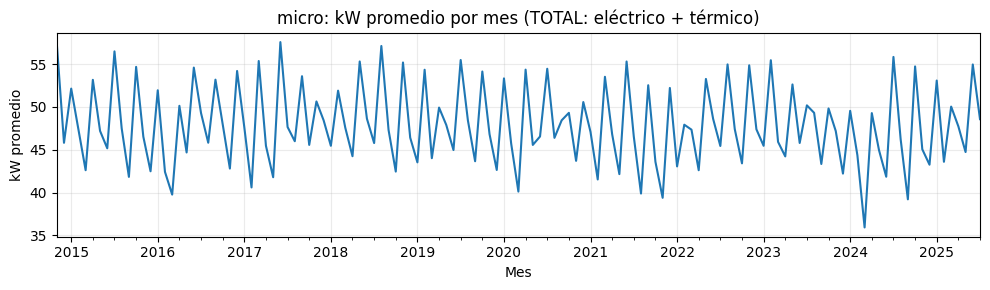

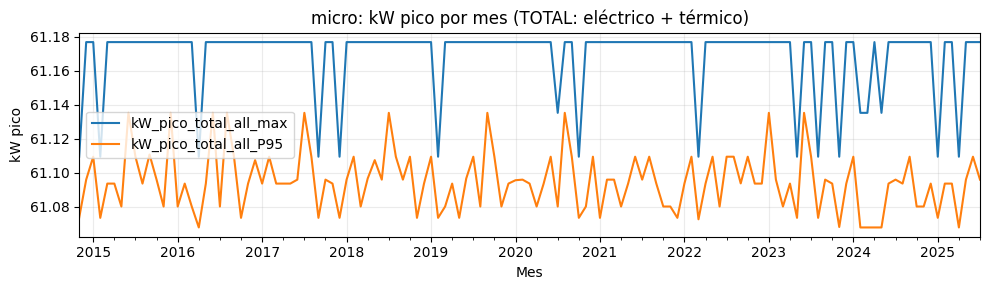

Escenario: pequeno


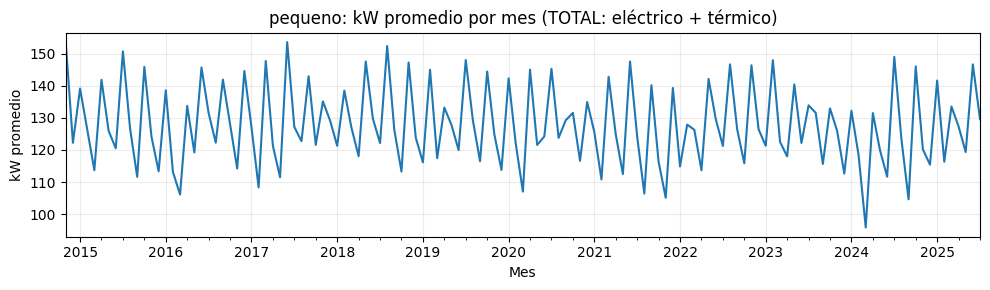

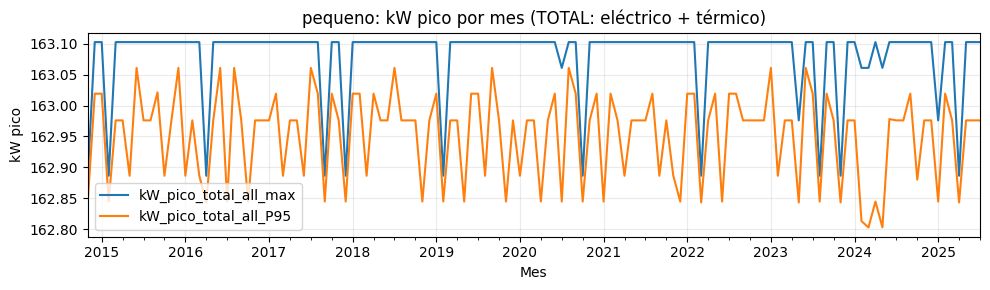

Escenario: mayor


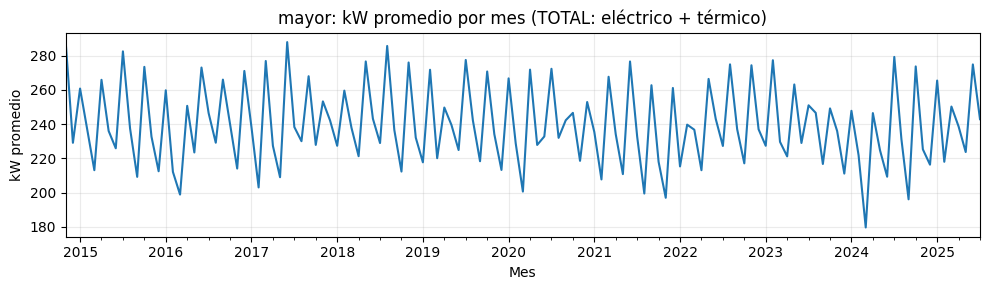

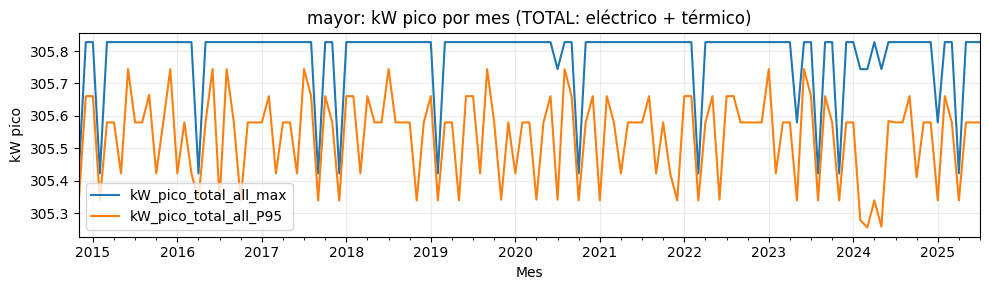

In [ ]:
# =Bloque 9=== Gráficas mensuales del TOTAL (eléctrico + térmico) ====
# kW_prom_mes = (Σ kWh_total_all del mes) / (Σ horas del mes)
# kW_pico_mes_max = max( kWh_total_all_intervalo / Δt_intervalo )
# kW_pico_mes_p95 = quantile_0.95( kWh_total_all_intervalo / Δt_intervalo )

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

for nombre, dfesc in resultados.items():
    print("Escenario:", nombre)
    s = dfesc.copy()
    s["t"] = pd.to_datetime(s["t"], errors="coerce").dt.tz_localize(None)
    s = s.dropna(subset=["t"]).sort_values("t").set_index("t")

    # ---- Asegura TOTAL (eléctrico + térmico) ----
    # Preferimos kWh_total_all; si falta, lo componemos como kWh_total_elec + kWh_fuel_heat
    if "kWh_total_all" in s.columns:
        total_col = "kWh_total_all"
    else:
        comp = []
        if "kWh_total_elec" in s.columns:
            comp.append("kWh_total_elec")
        else:
            # Si no hay total eléctrico, intenta sumar componentes eléctricos
            sub = [c for c in ["kWh_heat_elec","kWh_light","kWh_vent","kWh_pump"] if c in s.columns]
            if sub:
                s["kWh_total_elec"] = s[sub].sum(axis=1, min_count=1)
                comp.append("kWh_total_elec")
        if "kWh_fuel_heat" in s.columns:
            comp.append("kWh_fuel_heat")
        if comp:
            s["kWh_total_all"] = s[comp].sum(axis=1, min_count=1)
            total_col = "kWh_total_all"
        else:
            print(f"[{nombre}] No hay datos suficientes para total (eléctrico + térmico).")
            continue

    # Δt real (horas) con salvaguardas
    dt_h = s.index.to_series().diff().dt.total_seconds().div(3600.0)
    med  = dt_h.median() if pd.notna(dt_h.median()) and dt_h.median() > 0 else 1.0
    dt_h = dt_h.fillna(med).clip(lower=0.25, upper=4.0)

    # --- kW promedio mensual  ---
    energia_mes = s[total_col].resample("MS").sum()
    horas_mes   = dt_h.resample("MS").sum()
    kW_prom_mes = energia_mes.div(horas_mes.where(horas_mes > 0))
    ax = kW_prom_mes.rename("kW_prom_total_all").plot(
        figsize=(10,3), title=f"{nombre}: kW promedio por mes (TOTAL: eléctrico + térmico)"
    )
    ax.set_xlabel("Mes"); ax.set_ylabel("kW promedio"); ax.grid(True, alpha=.25)
    plt.tight_layout(); plt.show(); plt.close()

    # --- kW pico mensual (TOTAL): máximo y pico P95 ---
    kW_inst = s[total_col].div(dt_h.where(dt_h > 0))              # kW por intervalo (TOTAL)
    # Limpieza numérica
    kW_inst = kW_inst.replace([np.inf, -np.inf], np.nan).dropna()

    kW_pico_mes_max  = kW_inst.resample("MS").max().rename("kW_pico_total_all_max")
    kW_pico_mes_p95  = kW_inst.resample("MS").quantile(0.95).rename("kW_pico_total_all_P95")

    ax = pd.concat([kW_pico_mes_max, kW_pico_mes_p95], axis=1).plot(
        figsize=(10,3), title=f"{nombre}: kW pico por mes (TOTAL: eléctrico + térmico)"
    )
    ax.set_xlabel("Mes"); ax.set_ylabel("kW pico"); ax.grid(True, alpha=.25)
    plt.tight_layout(); plt.show(); plt.close()


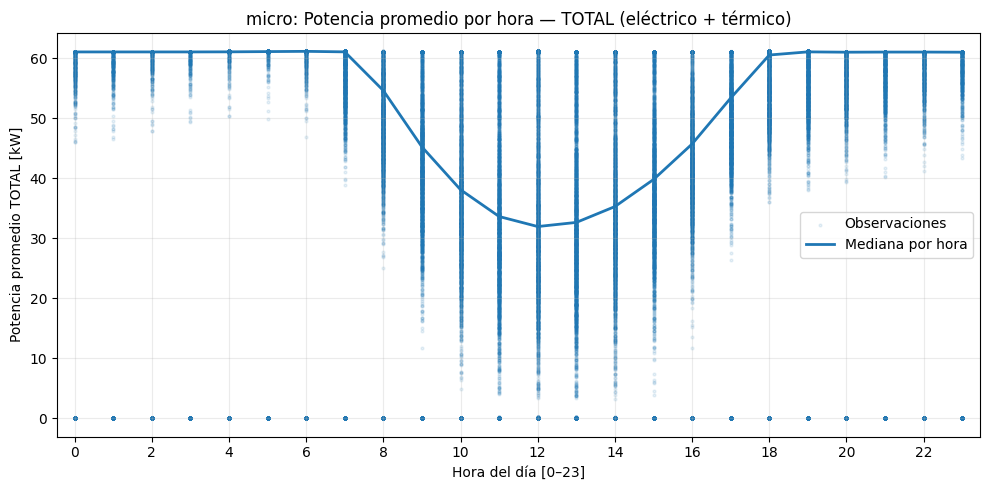

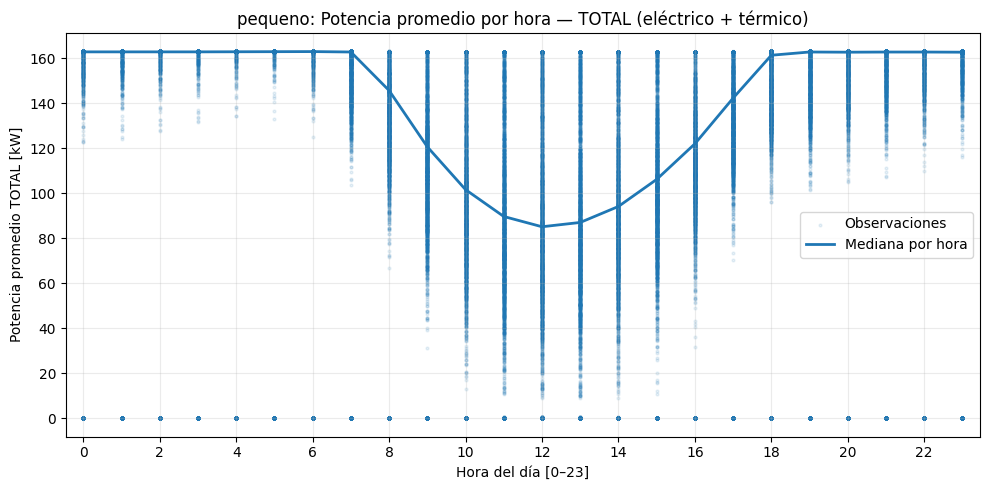

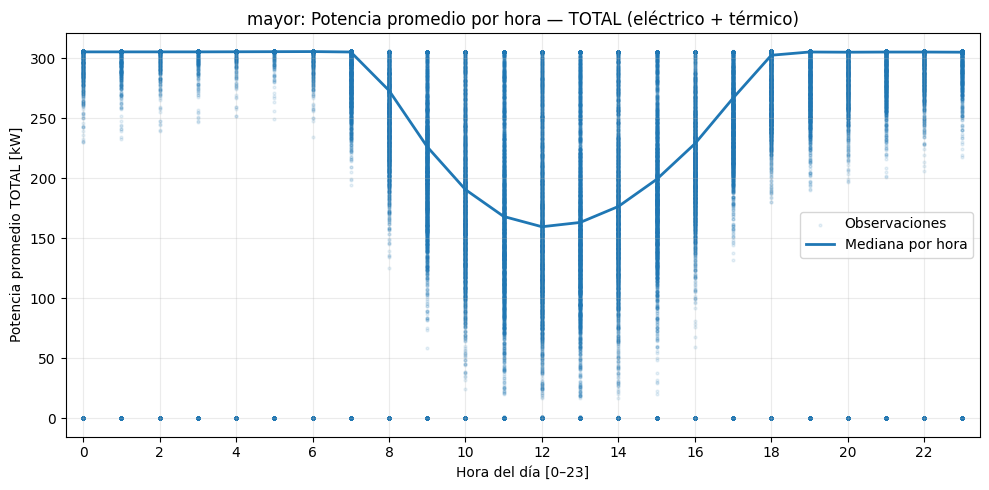

In [ ]:
# ===== Bloque 10 : Dispersión horario por tamaño (TOTAL) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Escenarios disponibles
ESC_NOMBRES = [k for k in ["micro", "pequeno", "mayor"] if k in resultados]

# Prioriza TOTAL (eléctrico + térmico);
TOTAL_CANDIDATAS = ["kWh_total_all", "kWh_total_elec", "kWh_total", "kWh_elec_total"]
COMPONENTES_POSIBLES = ["kWh_heat_elec", "kWh_light", "kWh_vent", "kWh_pump", "kWh_fuel_heat"]

# Parámetros de visualización
WINSOR_P_LOW  = 0.01
WINSOR_P_HIGH = 0.99

for esc in ESC_NOMBRES:
    d = resultados[esc].copy()

    # --- Tiempo local y hora ---
    t = pd.to_datetime(d["t"], errors="coerce")
    if getattr(t.dt, "tz", None) is not None:
        t = t.dt.tz_convert("America/Bogota").dt.tz_localize(None)
    d["t"] = t
    d = d.dropna(subset=["t"]).sort_values("t")
    d["hora"] = d["t"].dt.hour

    # --- Selección de columna total ---
    total_col = next((c for c in TOTAL_CANDIDATAS if c in d.columns), None)
    if total_col is None:
        comp_elec = [c for c in ["kWh_heat_elec","kWh_light","kWh_vent","kWh_pump"] if c in d.columns]
        if comp_elec:
            d["kWh_total_elec_auto"] = d[comp_elec].sum(axis=1, min_count=1)
        if comp_elec or ("kWh_fuel_heat" in d):
            d["kWh_total_all_auto"] = d.get("kWh_total_elec_auto", 0) + d.get("kWh_fuel_heat", 0)
            total_col = "kWh_total_all_auto"
        else:
            print(f"[{esc}] No hay columna total ni componentes conocidos. Se omite.")
            continue
    else:
        d[total_col] = pd.to_numeric(d[total_col], errors="coerce")

    # --- Limpieza y Δt real ---
    d = d.replace([np.inf, -np.inf], np.nan).dropna(subset=[total_col, "hora"])
    d = d[d[total_col] >= 0]
    if d.empty:
        print(f"[{esc}] Sin datos válidos tras limpieza; se omite.")
        continue

    dt_h = d["t"].diff().dt.total_seconds().div(3600.0)
    fill_dt = dt_h.median() if pd.notna(dt_h.median()) and dt_h.median() > 0 else 1.0
    dt_h = dt_h.fillna(fill_dt).clip(lower=0.25, upper=4.0)

    # kW promedio por intervalo
    d["kW_prom"] = np.clip(d[total_col].astype(float).div(dt_h, axis=0), 0.0, None)

    # --- Winsorización visual  ---
    if len(d) >= 50:
        q_lo, q_hi = d["kW_prom"].quantile([WINSOR_P_LOW, WINSOR_P_HIGH]).values
        d["kW_vis"] = d["kW_prom"].clip(lower=float(q_lo), upper=float(q_hi))
    else:
        d["kW_vis"] = d["kW_prom"]

    # Mediana por hora
    g = (
        d.groupby("hora")["kW_vis"]
         .median()
         .reset_index(name="p50")
         .sort_values("hora")
    )

    # --- Gráfica  ---
    plt.figure(figsize=(10, 5))
    plt.scatter(d["hora"], d["kW_vis"], s=4, alpha=0.10, label="Observaciones")
    plt.plot(g["hora"], g["p50"], linewidth=2.0, label="Mediana por hora")

    plt.title(f"{esc}: Potencia promedio por hora — TOTAL (eléctrico + térmico)")
    plt.xlabel("Hora del día [0–23]")
    plt.ylabel("Potencia promedio TOTAL [kW]")
    plt.xticks(range(0, 24, 2))
    plt.grid(True, alpha=0.25)
    plt.margins(x=0.02, y=0.05)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()


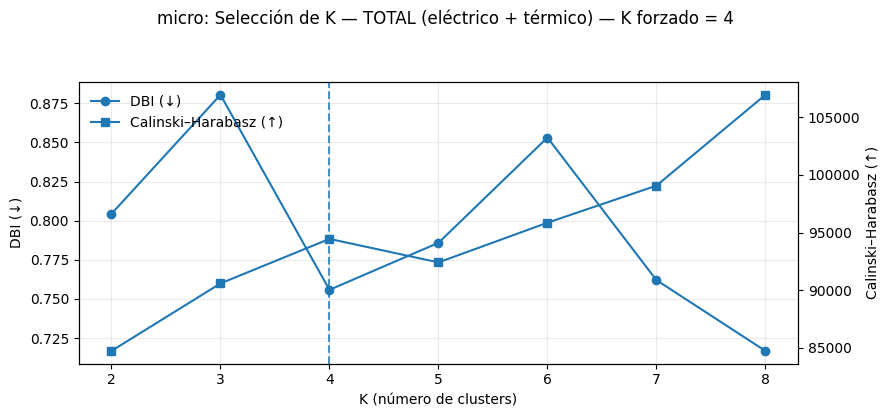

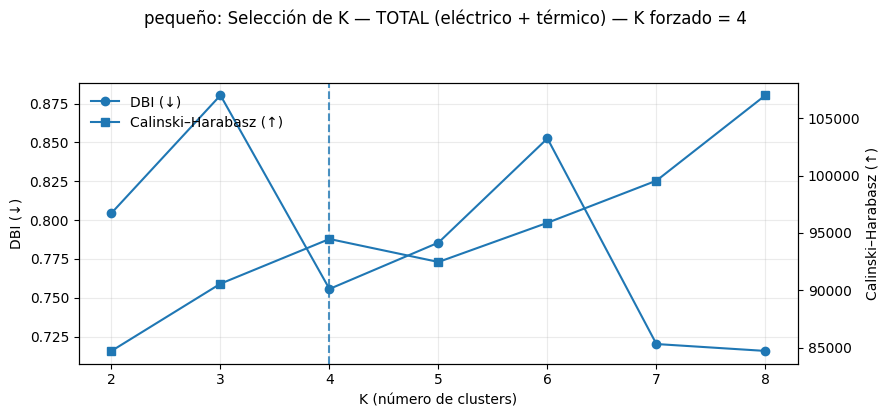

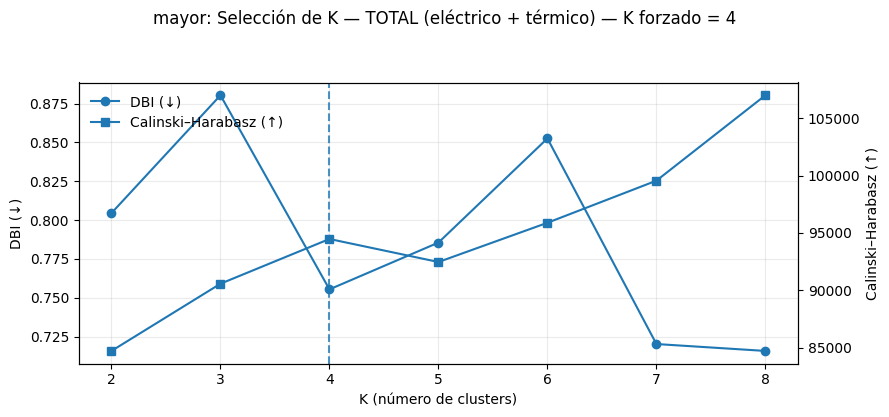

In [ ]:
# ===== Bloque 11 (TOTAL: eléctrico + térmico) — Selección de K con DBI & CH, K=4 =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

# --- Escenarios disponibles  ---
ESC_NOMBRES = [k for k in ["micro","pequeno","mayor"] if k in resultados]

# --- PRIORIDAD: TOTAL (eléctrico + térmico), luego variantes; como último recurso suma de componentes ---
TOTAL_CANDIDATAS = ["kWh_total_all", "kWh_total", "kWh_elec_total", "kWh_total_elec"]
COMP_ELEC = ["kWh_heat_elec","kWh_light","kWh_vent","kWh_pump"]  # recomponer total eléctrico si hiciera falta

K_RANGE = range(2, 9)
K_FORCE = 4
RANDOM_STATE = 123
MAX_N = 200_000  # muestreo para estabilidad/velocidad

def _t_bogota_naive(ts: pd.Series) -> pd.Series:
    t = pd.to_datetime(ts, errors="coerce")
    if getattr(t.dt, "tz", None) is not None:
        t = t.dt.tz_convert("America/Bogota").dt.tz_localize(None)
    return t

def _serie_total_kWh(df: pd.DataFrame) -> pd.DataFrame:
    """
    Devuelve DataFrame ordenado por tiempo con columnas:
      ['t', 'kWh_total', 'hay_lote']
    Donde kWh_total = eléctrico + térmico (combustible) por intervalo.
    """
    t_norm = _t_bogota_naive(df["t"])

    total_col = next((c for c in TOTAL_CANDIDATAS if c in df.columns), None)
    if total_col is not None:
        total_kWh = pd.to_numeric(df[total_col], errors="coerce")
    else:
        # Construir total = total_elec + kWh_fuel_heat
        if "kWh_total_elec" in df.columns:
            elec = pd.to_numeric(df["kWh_total_elec"], errors="coerce")
        else:
            comp_elec = [c for c in COMP_ELEC if c in df.columns]
            elec = df[comp_elec].sum(axis=1, min_count=1) if comp_elec else None
        fuel = pd.to_numeric(df["kWh_fuel_heat"], errors="coerce") if "kWh_fuel_heat" in df.columns else None
        if elec is None and fuel is None:
            raise ValueError("No hay columnas suficientes para construir el TOTAL (eléctrico + térmico).")
        if elec is None: elec = pd.Series(0.0, index=df.index, dtype=float)
        if fuel is None: fuel = pd.Series(0.0, index=df.index, dtype=float)
        total_kWh = elec.add(fuel, fill_value=0.0)

    hay = df["hay_lote"] if "hay_lote" in df.columns else pd.Series(1, index=df.index)
    d = (pd.DataFrame({"t": t_norm, "kWh_total": total_kWh, "hay_lote": hay})
           .replace([np.inf, -np.inf], np.nan)
           .dropna(subset=["t", "kWh_total"]))
    d = d[d["kWh_total"] >= 0].sort_values("t").reset_index(drop=True)
    d["hay_lote"] = pd.to_numeric(d["hay_lote"], errors="coerce").fillna(1).clip(0,1).astype(int)
    return d

def _to_kW_df(d_sorted: pd.DataFrame) -> pd.DataFrame:
    dt_h = d_sorted["t"].diff().dt.total_seconds().div(3600.0)
    med  = dt_h.median() if pd.notna(dt_h.median()) and dt_h.median() > 0 else 1.0
    dt_h = dt_h.fillna(med).clip(lower=0.25, upper=4.0)
    kW   = d_sorted["kWh_total"].div(dt_h)
    out  = pd.DataFrame({"t": d_sorted["t"].values, "kW": kW.values, "hay_lote": d_sorted["hay_lote"].values})
    out["hora"] = pd.to_datetime(out["t"]).dt.hour.astype(int)
    return out.replace([np.inf, -np.inf], np.nan).dropna(subset=["kW","hora"])

def _prep_X_sin_vacio_y_ceros(df: pd.DataFrame):
    d = _serie_total_kWh(df)
    x = _to_kW_df(d)
    x = x[(x["hay_lote"] == 1) & (x["kW"] > 0)]
    if x.empty: return None, None
    q99 = x["kW"].quantile(0.99)
    if pd.notna(q99) and q99 > 0:
        x.loc[:, "kW"] = np.minimum(x["kW"].to_numpy(), q99)
    ang   = 2*np.pi*(x["hora"].astype(float)/24.0)
    sin_h = np.sin(ang).to_numpy().reshape(-1,1)
    cos_h = np.cos(ang).to_numpy().reshape(-1,1)
    sc   = StandardScaler().fit(x["kW"].to_numpy().reshape(-1,1))
    z_kW = sc.transform(x["kW"].to_numpy().reshape(-1,1))
    X = np.hstack([sin_h, cos_h, z_kW])
    return X, {"n": X.shape[0]}

# ===== Evaluación de K por escenario =====
for esc in ESC_NOMBRES:
    esc_titulo = {"pequeno": "pequeño"}.get(esc, esc)

    X, meta = _prep_X_sin_vacio_y_ceros(resultados[esc])
    if X is None or meta["n"] < 2:
        print(f"[{esc}] Datos insuficientes tras filtros; se omite.")
        continue

    # Muestreo para estabilidad/velocidad
    if X.shape[0] > MAX_N:
        rng = np.random.default_rng(RANDOM_STATE)
        idx = rng.choice(X.shape[0], size=MAX_N, replace=False)
        X_eval = X[idx]
    else:
        X_eval = X

    dbi, ch, ks = [], [], []
    for K in K_RANGE:
        if X_eval.shape[0] <= K:
            continue
        km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=50, max_iter=1000, algorithm="elkan")
        labels = km.fit_predict(X_eval)
        dbi.append(davies_bouldin_score(X_eval, labels))    # ↓ mejor
        ch.append(calinski_harabasz_score(X_eval, labels))  # ↑ mejor
        ks.append(K)

    if not ks:
        print(f"[{esc}] No se pudieron evaluar K en el rango (muestras={X_eval.shape[0]}).")
        continue

    fig, ax1 = plt.subplots(figsize=(9,4))
    l1, = ax1.plot(ks, dbi, marker="o", label="DBI (↓)")
    ax1.set_xlabel("K (número de clusters)")
    ax1.set_ylabel("DBI (↓)")
    ax1.grid(True, alpha=.25)

    ax2 = ax1.twinx()
    l2, = ax2.plot(ks, ch, marker="s", label="Calinski–Harabasz (↑)")
    ax2.set_ylabel("Calinski–Harabasz (↑)")

    if K_FORCE in ks:
        ax1.axvline(K_FORCE, linestyle="--", linewidth=1.5, alpha=0.8)


    ax1.legend(handles=[l1, l2], loc="upper left", frameon=False)


    fig.suptitle(f"{esc_titulo}: Selección de K — TOTAL (eléctrico + térmico) — K forzado = {K_FORCE}", y=1.03, fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    plt.show()
    plt.close()


/tmp/ipython-input-899011593.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), per_hour_max), random_state=random_state))
/tmp/ipython-input-899011593.py:114: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scale = float(sc.scale_) if float(sc.scale_) != 0.0 else 1.0
/tmp/ipython-input-899011593.py:115: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing th

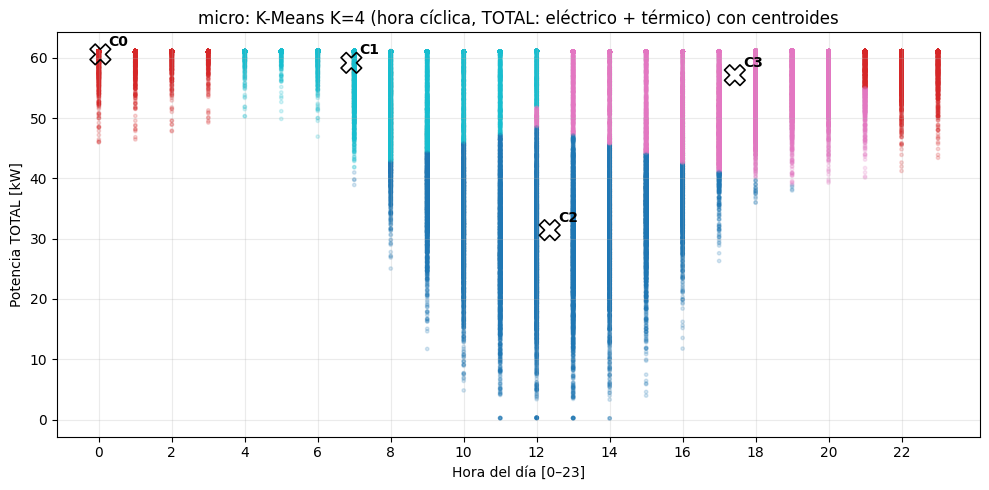


Centroides en unidades reales — micro
 hora_media  kW_centroid
       0.04        60.57
       6.92        59.17
      12.36        31.41
      17.43        57.12


/tmp/ipython-input-899011593.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), per_hour_max), random_state=random_state))
/tmp/ipython-input-899011593.py:114: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scale = float(sc.scale_) if float(sc.scale_) != 0.0 else 1.0
/tmp/ipython-input-899011593.py:115: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing th

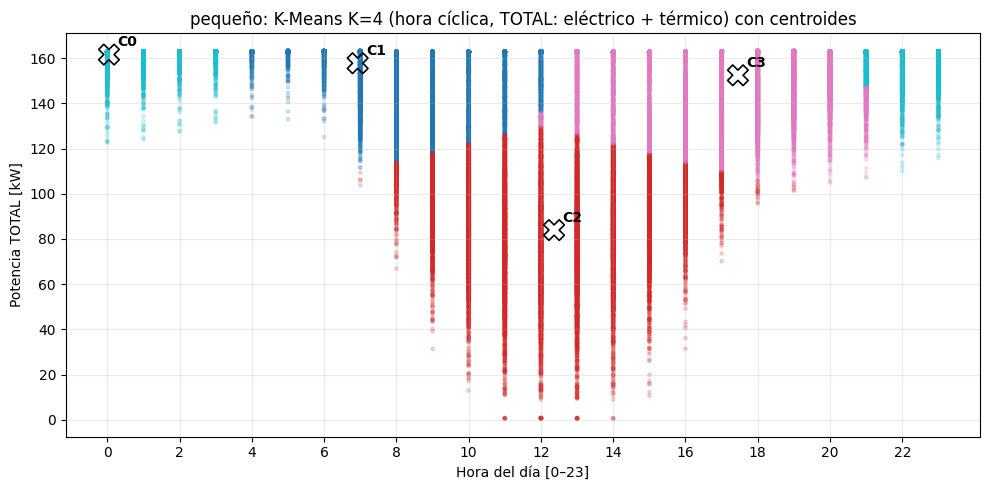


Centroides en unidades reales — pequeño
 hora_media  kW_centroid
       0.04       161.60
       6.93       157.77
      12.36        83.94
      17.45       152.44


/tmp/ipython-input-899011593.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), per_hour_max), random_state=random_state))
/tmp/ipython-input-899011593.py:114: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scale = float(sc.scale_) if float(sc.scale_) != 0.0 else 1.0
/tmp/ipython-input-899011593.py:115: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing th

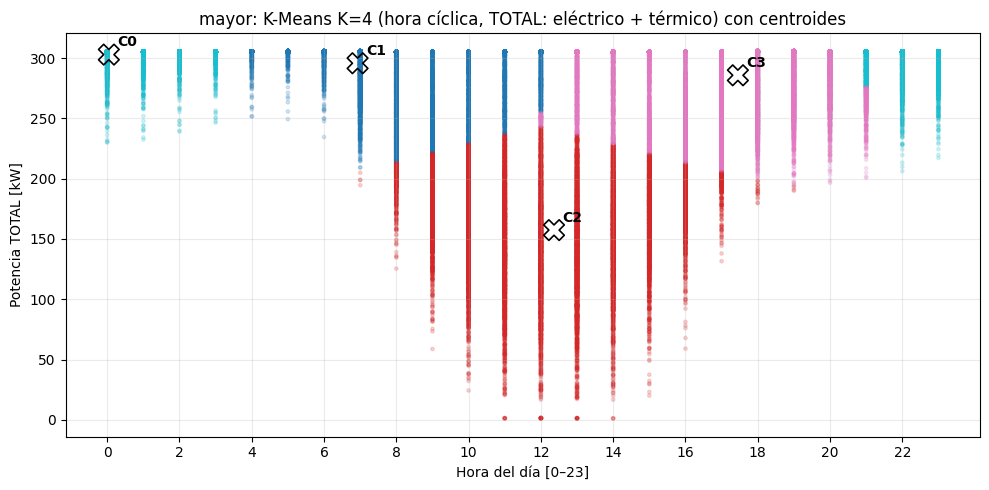


Centroides en unidades reales — mayor
 hora_media  kW_centroid
       0.04       303.00
       6.93       295.82
      12.36       157.38
      17.45       285.84


In [ ]:
# ==Bloque 12=== K-Means K=4 por tamaño: hora cíclica + kW TOTAL (Δt real)  =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Prioriza TOTAL (eléctrico + térmico); luego variantes; último recurso: solo eléctrico
TOTAL_CANDIDATAS = ["kWh_total_all", "kWh_total", "kWh_elec_total", "kWh_total_elec"]
COMP_ELEC = ["kWh_heat_elec", "kWh_light", "kWh_vent", "kWh_pump"]

def _t_bogota_naive(ts: pd.Series) -> pd.Series:
    """Normaliza timestamps a Bogotá (naive, sin tz)."""
    t = pd.to_datetime(ts, errors="coerce")
    if getattr(t.dt, "tz", None) is not None:
        t = t.dt.tz_convert("America/Bogota").dt.tz_localize(None)
    return t

def _build_sorted_df_total(df: pd.DataFrame) -> pd.DataFrame:
    """
    Devuelve DF ordenado por tiempo con columnas ['t','kWh_total','hay_lote'].
    kWh_total = TOTAL (eléctrico + térmico). Si no existe, lo compone como:
        (kWh_total_elec o suma de componentes eléctricos) + kWh_fuel_heat (si existe).
    """
    t = _t_bogota_naive(df["t"])


    tot_col = next((c for c in TOTAL_CANDIDATAS if c in df.columns), None)
    if tot_col is not None:
        tot = pd.to_numeric(df[tot_col], errors="coerce")
    else:

        if "kWh_total_elec" in df.columns:
            elec = pd.to_numeric(df["kWh_total_elec"], errors="coerce")
        else:
            comp = [c for c in COMP_ELEC if c in df.columns]
            elec = df[comp].sum(axis=1, min_count=1) if comp else None
        fuel = pd.to_numeric(df["kWh_fuel_heat"], errors="coerce") if "kWh_fuel_heat" in df.columns else None

        if elec is None and fuel is None:
            raise ValueError("No hay columnas suficientes para construir el TOTAL (eléctrico + térmico).")
        if elec is None: elec = pd.Series(0.0, index=df.index, dtype=float)
        if fuel is None: fuel = pd.Series(0.0, index=df.index, dtype=float)
        tot = elec.add(fuel, fill_value=0.0)

    hay = df["hay_lote"] if "hay_lote" in df.columns else pd.Series(1, index=df.index)

    d = (pd.DataFrame({"t": t, "kWh_total": tot, "hay_lote": hay})
           .replace([np.inf, -np.inf], np.nan)
           .dropna(subset=["t","kWh_total"]))
    d = d[d["kWh_total"] >= 0].sort_values("t").reset_index(drop=True)
    d["hay_lote"] = pd.to_numeric(d["hay_lote"], errors="coerce").fillna(1).clip(0,1).astype(int)
    return d

def _to_kW_from_sorted(d_sorted: pd.DataFrame) -> pd.DataFrame:
    """Calcula kW = kWh/Δt (Δt en horas reales) y agrega 'hora'."""
    dt_h = d_sorted["t"].diff().dt.total_seconds().div(3600.0)
    med  = dt_h.median() if pd.notna(dt_h.median()) and dt_h.median() > 0 else 1.0
    dt_h = dt_h.fillna(med).clip(lower=0.25, upper=4.0)
    kW   = d_sorted["kWh_total"].div(dt_h)

    out = pd.DataFrame({
        "t": d_sorted["t"].values,
        "kW": kW.values,
        "hay_lote": d_sorted["hay_lote"].values
    })
    out["hora"] = pd.to_datetime(out["t"]).dt.hour.astype(int)
    out = out.replace([np.inf, -np.inf], np.nan).dropna(subset=["kW","hora"])
    return out

def _prep_cyclic_features(df, balance_by_hour=False, per_hour_max=None, random_state=123):
    """
    Prepara datos para K-Means:
      - Filtra vacío (hay_lote==1) y kW>0
      - kWh→kW con Δt real
      - Winsoriza kW en P99 (suaviza picos cortos)
      - Estandariza kW (z-score)
      - Hora cíclica → (sin, cos)
      - (Opcional) balance por hora
    Devuelve: d_limpio[['hora','kW']], X=[sin,cos,z_kW], meta
    """
    d_sorted = _build_sorted_df_total(df)
    x = _to_kW_from_sorted(d_sorted)

    # filtros físicos
    x = x[(x["hay_lote"] == 1) & (x["kW"] > 0)]
    if x.empty:
        return None, None, None

    # balancear por hora
    if balance_by_hour:
        if per_hour_max is None:
            per_hour_max = int(x["hora"].value_counts().median())
        per_hour_max = max(int(per_hour_max), 1)
        x = (x.groupby("hora", group_keys=False)
               .apply(lambda g: g.sample(n=min(len(g), per_hour_max), random_state=random_state))
               .reset_index(drop=True))

    # winsorización superior
    if len(x) >= 20:
        q99 = x["kW"].quantile(0.99)
        x["kW_clip"] = np.minimum(x["kW"], q99) if pd.notna(q99) and q99 > 0 else x["kW"]
    else:
        x["kW_clip"] = x["kW"]

    # hora cíclica
    w = 2*np.pi/24.0
    theta = w * x["hora"].astype(float).to_numpy()
    sin_h = np.sin(theta).reshape(-1,1)
    cos_h = np.cos(theta).reshape(-1,1)

    # z-score de kW
    sc = StandardScaler().fit(x["kW_clip"].to_numpy().reshape(-1,1))
    scale = float(sc.scale_) if float(sc.scale_) != 0.0 else 1.0
    z_kW = (x["kW_clip"].to_numpy().reshape(-1,1) - float(sc.mean_)) / scale

    X = np.hstack([sin_h, cos_h, z_kW])
    meta = {"scaler_mean": float(sc.mean_), "scaler_scale": scale, "w": w}
    return x[["hora","kW"]].copy(), X, meta

def _invert_center(center_row, meta):
    """Convierte un centroide [sin, cos, z_kW] → (hora_real 0..24, kW_real)."""
    sin_c, cos_c, z_c = center_row
    ang = np.arctan2(sin_c, cos_c)            # (-π, π]
    h_real = (ang % (2*np.pi)) / meta["w"]    # [0,24)
    kW_real = z_c * meta["scaler_scale"] + meta["scaler_mean"]
    return float(h_real), float(kW_real)

def kmeans_hora_ciclica(df, K=4, balance_by_hour=True, per_hour_max=None,
                        seed=123, n_init=50, max_iter=1000):
    """
    Ajusta K-Means con (sin_h, cos_h, z_kW) sobre kW TOTAL.
    Devuelve:
      df_lab: filas usadas (hora, kW, cluster)
      cents : centroides en unidades reales (hora_media, kW_centroid), ordenados por hora.
    """
    d, X, meta = _prep_cyclic_features(df, balance_by_hour=balance_by_hour,
                                       per_hour_max=per_hour_max, random_state=seed)
    if X is None or len(d) < K:
        raise ValueError(f"Datos insuficientes tras limpieza para K={K} (n={0 if X is None else len(d)}).")

    km = KMeans(n_clusters=K, random_state=seed, n_init=n_init, max_iter=max_iter)
    labels = km.fit_predict(X)

    cents = []
    for c in km.cluster_centers_:
        h, p = _invert_center(c, meta)
        cents.append((h, p))
    cents = (pd.DataFrame(cents, columns=["hora_media","kW_centroid"])
               .sort_values("hora_media").reset_index(drop=True))

    df_lab = d.copy()
    df_lab["cluster"] = labels
    return df_lab, cents

def plot_kmeans_por_tamano(resultados_dict, K=4, balance_by_hour=True, per_hour_max=None, seed=123):
    ESCENES = [k for k in ["micro","pequeno","mayor"] if k in resultados_dict]
    for esc in ESCENES:
        df_lab, cents = kmeans_hora_ciclica(resultados_dict[esc], K=K,
                                            balance_by_hour=balance_by_hour,
                                            per_hour_max=per_hour_max, seed=seed)
        esc_titulo = {"pequeno": "pequeño"}.get(esc, esc)

        plt.figure(figsize=(10,5))
        plt.scatter(df_lab["hora"], df_lab["kW"], c=df_lab["cluster"], s=6, alpha=0.18, cmap="tab10")
        plt.scatter(cents["hora_media"], cents["kW_centroid"],
                    s=220, marker="X", edgecolors="k", linewidths=1.2, facecolors="none", zorder=5)
        for i, r in cents.iterrows():
            plt.annotate(f"C{i}", (r["hora_media"], r["kW_centroid"]),
                         textcoords="offset points", xytext=(6,6), fontsize=10, weight="bold")

        plt.title(f"{esc_titulo}: K-Means K={K} (hora cíclica, TOTAL: eléctrico + térmico) con centroides")
        plt.xlabel("Hora del día [0–23]"); plt.ylabel("Potencia TOTAL [kW]")
        plt.xticks(range(0,24,2)); plt.grid(True, alpha=.25)
        plt.tight_layout(); plt.show()

        print(f"\nCentroides en unidades reales — {esc_titulo}")
        print(cents.round(2).to_string(index=False))


plot_kmeans_por_tamano(resultados, K=4, balance_by_hour=True, per_hour_max=None, seed=123)


/tmp/ipython-input-899011593.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), per_hour_max), random_state=random_state))
/tmp/ipython-input-899011593.py:114: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scale = float(sc.scale_) if float(sc.scale_) != 0.0 else 1.0
/tmp/ipython-input-899011593.py:115: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing th

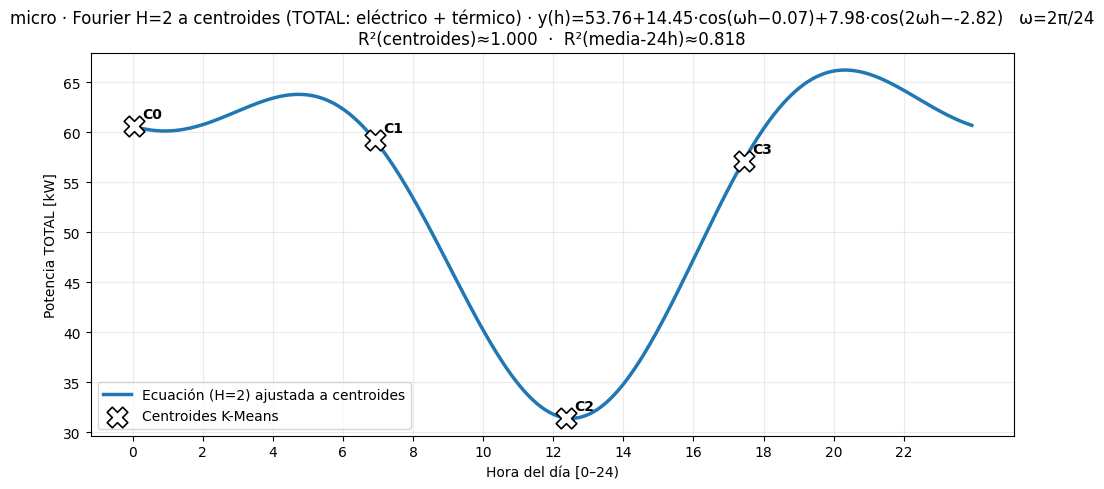


[micro] Ecuación (interpola centroides, kW TOTAL):
  y(h)=53.76+14.45·cos(ωh−0.07)+7.98·cos(2ωh−-2.82)   ω=2π/24
  Centroides (hora_media, kW):
 hora_media  kW_centroid
       0.04        60.57
       6.92        59.17
      12.36        31.41
      17.43        57.12
  R² en centroides = 1.0000 (≈1.000)
  R² vs media por hora (24 pts, kW) = 0.8184


/tmp/ipython-input-899011593.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), per_hour_max), random_state=random_state))
/tmp/ipython-input-899011593.py:114: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scale = float(sc.scale_) if float(sc.scale_) != 0.0 else 1.0
/tmp/ipython-input-899011593.py:115: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing th

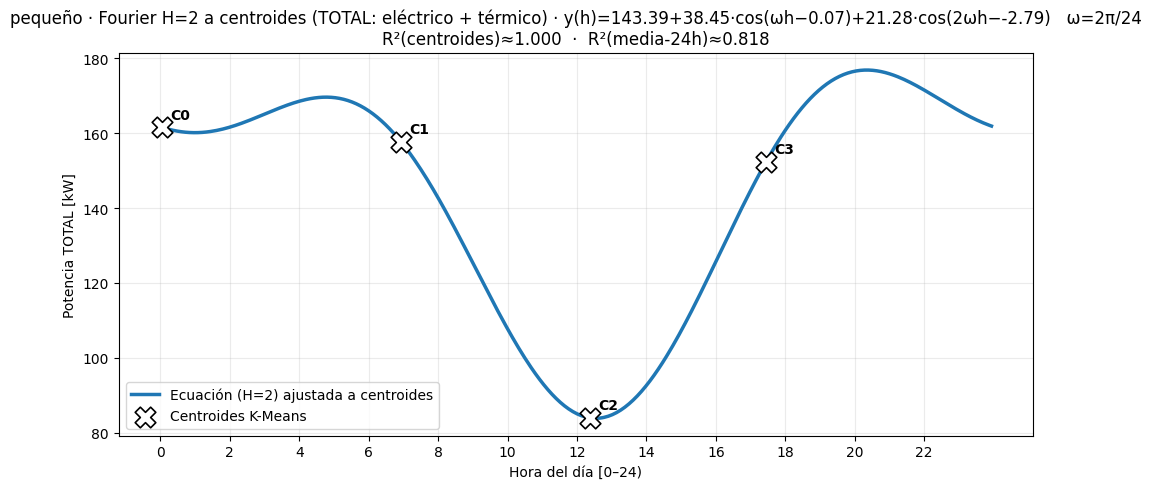


[pequeño] Ecuación (interpola centroides, kW TOTAL):
  y(h)=143.39+38.45·cos(ωh−0.07)+21.28·cos(2ωh−-2.79)   ω=2π/24
  Centroides (hora_media, kW):
 hora_media  kW_centroid
       0.04       161.60
       6.93       157.77
      12.36        83.94
      17.45       152.44
  R² en centroides = 1.0000 (≈1.000)
  R² vs media por hora (24 pts, kW) = 0.8178


/tmp/ipython-input-899011593.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), per_hour_max), random_state=random_state))
/tmp/ipython-input-899011593.py:114: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scale = float(sc.scale_) if float(sc.scale_) != 0.0 else 1.0
/tmp/ipython-input-899011593.py:115: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing th

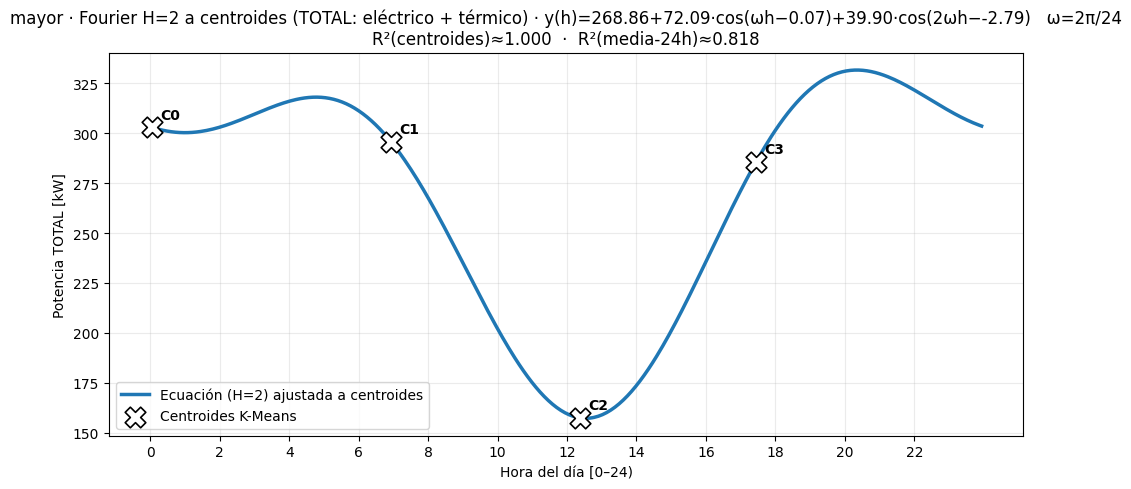


[mayor] Ecuación (interpola centroides, kW TOTAL):
  y(h)=268.86+72.09·cos(ωh−0.07)+39.90·cos(2ωh−-2.79)   ω=2π/24
  Centroides (hora_media, kW):
 hora_media  kW_centroid
       0.04       303.00
       6.93       295.82
      12.36       157.38
      17.45       285.84
  R² en centroides = 1.0000 (≈1.000)
  R² vs media por hora (24 pts, kW) = 0.8178


In [ ]:
# ===== BLOQUE 13— Fourier H=2 AJUSTADO A CENTROIDES =====

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Fallbacks ---
TOTAL_CANDIDATAS = ["kWh_total_all", "kWh_total", "kWh_elec_total", "kWh_total_elec"]
COMP_ELEC = ["kWh_heat_elec","kWh_light","kWh_vent","kWh_pump"]

def _serie_t_y_total_kWh_fallback(df: pd.DataFrame):
    t = pd.to_datetime(df["t"], errors="coerce")
    if getattr(t.dt, "tz", None) is not None:
        t = t.dt.tz_convert("America/Bogota").dt.tz_localize(None)

    # 1) Usa total si existe
    total_col = next((c for c in TOTAL_CANDIDATAS if c in df.columns), None)
    if total_col is not None:
        total_kWh = pd.to_numeric(df[total_col], errors="coerce")
    else:
        # 2) Construye: total = eléctrico + térmico
        if "kWh_total_elec" in df.columns:
            elec = pd.to_numeric(df["kWh_total_elec"], errors="coerce")
        else:
            comp = [c for c in COMP_ELEC if c in df.columns]
            elec = df[comp].sum(axis=1, min_count=1) if comp else None
        fuel = pd.to_numeric(df["kWh_fuel_heat"], errors="coerce") if "kWh_fuel_heat" in df.columns else None

        if elec is None and fuel is None:
            raise ValueError("No hay columnas para construir el TOTAL (eléctrico + térmico).")
        if elec is None: elec = pd.Series(0.0, index=df.index, dtype=float)
        if fuel is None: fuel = pd.Series(0.0, index=df.index, dtype=float)
        total_kWh = elec.add(fuel, fill_value=0.0)

    return t, total_kWh.replace([np.inf, -np.inf], np.nan)

def _kWh_a_kW_fallback(total_kWh: pd.Series, t: pd.Series):
    dt_h = t.diff().dt.total_seconds().div(3600.0)
    med = dt_h.median() if pd.notna(dt_h.median()) and dt_h.median() > 0 else 1.0
    dt_h = dt_h.fillna(med).clip(lower=0.25, upper=4.0)
    return total_kWh.div(dt_h)

def _get_t_y_kW(df: pd.DataFrame):
    # Usa helpers del bloque previo si existen; si no, usa fallbacks
    if "_serie_t_y_total_kWh" in globals():
        t, total_kWh = globals()["_serie_t_y_total_kWh"](df)
    else:
        t, total_kWh = _serie_t_y_total_kWh_fallback(df)
    if "_kWh_a_kW" in globals():
        kW = globals()["_kWh_a_kW"](total_kWh, t)
    else:
        kW = _kWh_a_kW_fallback(total_kWh, t)
    return t, kW

# --- Ajuste Fourier H=2 a centroides  ---
def fit_fourier_H2_from_centroids(cents: pd.DataFrame):
    """
    y(h) = A0 + A1*cos(ωh - φ1) + A2*cos(2ωh - φ2), ω=2π/24.
    Interpola EXACTO los centroides usando β* = Xᵀ (X Xᵀ)^(-1) y, con fallback numérico estable.
    """
    w = 2*np.pi/24.0
    y_col = "kW_centroid" if "kW_centroid" in cents.columns else "kWh_centroid"

    h = cents["hora_media"].to_numpy(dtype=float)
    y = cents[y_col].to_numpy(dtype=float)

    X = np.column_stack([
        np.ones_like(h),
        np.cos(w*h), np.sin(w*h),
        np.cos(2*w*h), np.sin(2*w*h),
    ])  # (K,5)

    M = X @ X.T
    try:
        beta = X.T @ np.linalg.solve(M, y)
    except np.linalg.LinAlgError:
        beta = X.T @ np.linalg.pinv(M) @ y

    A0, C1, S1, C2, S2 = beta
    A1, phi1 = float(np.hypot(C1, S1)), float(np.arctan2(S1, C1))
    A2, phi2 = float(np.hypot(C2, S2)), float(np.arctan2(S2, C2))

    def f_eval(hh):
        hh = np.asarray(hh, dtype=float)
        return (float(A0)
                + A1*np.cos(w*hh - phi1)
                + A2*np.cos(2*w*hh - phi2))

    y_hat = f_eval(h)
    ss_res = float(np.sum((y - y_hat)**2))
    ss_tot = float(np.sum((y - y.mean())**2))
    r2_cent = 1.0 - ss_res/ss_tot if ss_tot > 0 else 1.0

    return {
        "A0": float(A0), "A1": A1, "phi1": phi1,
        "A2": A2, "phi2": phi2, "omega": w,
        "r2_centroids": float(r2_cent), "f_eval": f_eval
    }

# --- R² vs media horaria (24 bins) en kW TOTAL ---
def r2_vs_media_horaria(df: pd.DataFrame, f_eval):
    """
    R² de la ecuación contra la media por hora (24 puntos) en kW TOTAL.
    Filtros: hay_lote==1 si existe y kW > 0.
    """
    t, kW = _get_t_y_kW(df)
    d = pd.DataFrame({"t": t, "kW": kW})

    # Copiar/crear hay_lote dentro de d
    if "hay_lote" in df.columns:
        hay = pd.to_numeric(df["hay_lote"], errors="coerce").fillna(1).astype(np.int8).to_numpy()
    else:
        hay = np.ones(len(d), dtype=np.int8)
    d["hay_lote"] = hay
    d = d[d["hay_lote"] == 1]

    d["hora"] = pd.to_datetime(d["t"], errors="coerce").dt.hour
    d = d.replace([np.inf, -np.inf], np.nan).dropna(subset=["kW","hora"])
    d = d[d["kW"] > 0]
    if d.empty:
        return np.nan

    g = d.groupby("hora", as_index=False)["kW"].mean().sort_values("hora")
    h = g["hora"].to_numpy(dtype=float)
    y = g["kW"].to_numpy(dtype=float)
    y_hat = f_eval(h)
    ss_res = float(np.sum((y - y_hat)**2))
    ss_tot = float(np.sum((y - y.mean())**2))
    return 1.0 - ss_res/ss_tot if ss_tot > 0 else 1.0

def plot_fourier_centroids_por_tamano(resultados_dict, K=4, balance_by_hour=True, per_hour_max=None):
    """
    Para cada tamaño ('micro','pequeno','mayor'):
      1) kmeans_hora_ciclica() → centroides (hora_media, kW_centroid).
      2) Ajuste Fourier H=2 (interpola exacto los centroides).
      3) Reporta R² en centroides y vs. media horaria (24 puntos).
      4) Grafica curva + centroides en dominio [0,24).
    """
    ESCENES = [k for k in ["micro","pequeno","mayor"] if k in resultados_dict]
    for esc in ESCENES:
        df = resultados_dict[esc]

        df_lab, cents = kmeans_hora_ciclica(df, K=K,
                                            balance_by_hour=balance_by_hour,
                                            per_hour_max=per_hour_max)

        fit = fit_fourier_H2_from_centroids(cents)
        r2_val = r2_vs_media_horaria(df, fit["f_eval"])

        # Curva suave en [0,24) (sin repetir 24)
        h_f = np.linspace(0, 24, 400, endpoint=False)
        y_f = fit["f_eval"](h_f)

        eq_txt = (f"y(h)={fit['A0']:.2f}"
                  f"+{fit['A1']:.2f}·cos(ωh−{fit['phi1']:.2f})"
                  f"+{fit['A2']:.2f}·cos(2ωh−{fit['phi2']:.2f})   ω=2π/24")

        esc_titulo = {"pequeno": "pequeño"}.get(esc, esc)

        plt.figure(figsize=(10,5))
        plt.plot(h_f, y_f, linewidth=2.5, label="Ecuación (H=2) ajustada a centroides")
        plt.scatter(cents["hora_media"], cents["kW_centroid"],
                    s=220, marker="X", edgecolors="k", linewidths=1.2,
                    facecolors="white", zorder=5, label="Centroides K-Means")
        for i, r in cents.iterrows():
            plt.annotate(f"C{i}", (r["hora_media"], r["kW_centroid"]),
                         textcoords="offset points", xytext=(6,6),
                         fontsize=10, weight="bold")

        plt.title(f"{esc_titulo} · Fourier H=2 a centroides (TOTAL: eléctrico + térmico) · {eq_txt}\n"
                  f"R²(centroides)≈{fit['r2_centroids']:.3f}  ·  R²(media-24h)≈{r2_val:.3f}")
        plt.xlabel("Hora del día [0–24)")
        plt.ylabel("Potencia TOTAL [kW]")
        plt.xticks(range(0,24,2))
        plt.grid(True, alpha=.25)
        plt.legend()
        plt.tight_layout()
        plt.show(); plt.close()

        print(f"\n[{esc_titulo}] Ecuación (interpola centroides, kW TOTAL):")
        print(f"  {eq_txt}")
        print("  Centroides (hora_media, kW):")
        print(cents.round(2).to_string(index=False))
        print(f"  R² en centroides = {fit['r2_centroids']:.4f} (≈1.000)")
        print(f"  R² vs media por hora (24 pts, kW) = {r2_val:.4f}")


plot_fourier_centroids_por_tamano(resultados, K=4, balance_by_hour=True, per_hour_max=None)


/tmp/ipython-input-899011593.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), per_hour_max), random_state=random_state))
/tmp/ipython-input-899011593.py:114: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scale = float(sc.scale_) if float(sc.scale_) != 0.0 else 1.0
/tmp/ipython-input-899011593.py:115: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing th

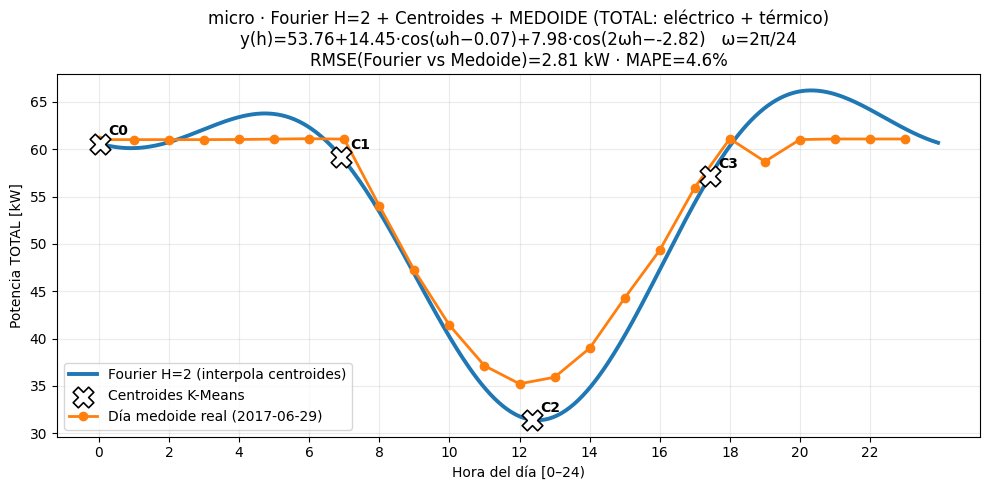


[micro] Medoide: 2017-06-29
RMSE(Fourier vs Medoide) = 2.812 kW
MAPE(Fourier vs Medoide) = 4.64 %
Serie 24h del medoide (kW TOTAL):
hora
0     61.01
1     61.01
2     61.01
3     61.01
4     61.03
5     61.07
6     61.11
7     61.07
8     54.02
9     47.20
10    41.42
11    37.13
12    35.23
13    35.92
14    38.98
15    44.28
16    49.33
17    55.95
18    61.11
19    58.70
20    61.02
21    61.08
22    61.08
23    61.08
------------------------------------------------------------


/tmp/ipython-input-899011593.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), per_hour_max), random_state=random_state))
/tmp/ipython-input-899011593.py:114: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scale = float(sc.scale_) if float(sc.scale_) != 0.0 else 1.0
/tmp/ipython-input-899011593.py:115: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing th

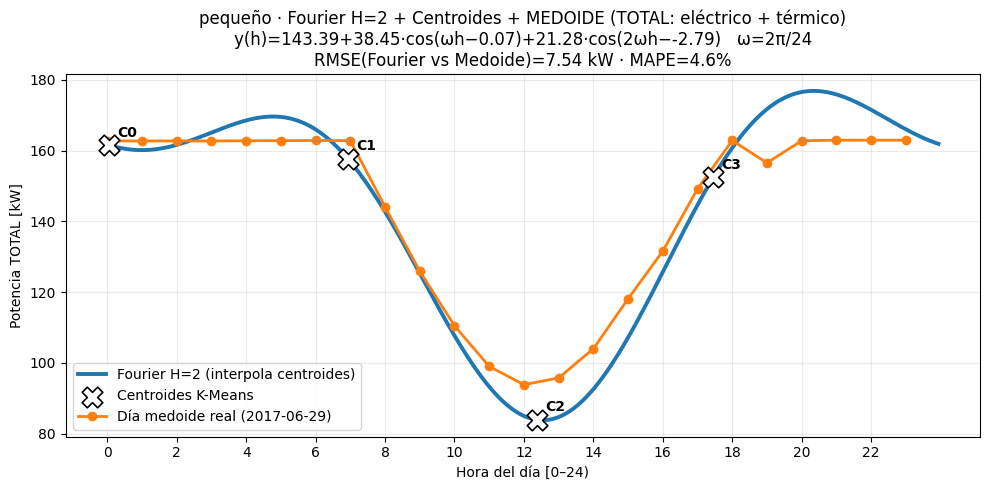


[pequeño] Medoide: 2017-06-29
RMSE(Fourier vs Medoide) = 7.535 kW
MAPE(Fourier vs Medoide) = 4.61 %
Serie 24h del medoide (kW TOTAL):
hora
0     162.76
1     162.76
2     162.76
3     162.76
4     162.80
5     162.84
6     162.89
7     162.84
8     144.13
9     125.94
10    110.51
11     99.02
12     93.87
13     95.77
14    104.01
15    118.14
16    131.62
17    149.20
18    162.89
19    156.56
20    162.81
21    162.98
22    162.98
23    162.98
------------------------------------------------------------


/tmp/ipython-input-899011593.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), per_hour_max), random_state=random_state))
/tmp/ipython-input-899011593.py:114: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scale = float(sc.scale_) if float(sc.scale_) != 0.0 else 1.0
/tmp/ipython-input-899011593.py:115: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing th

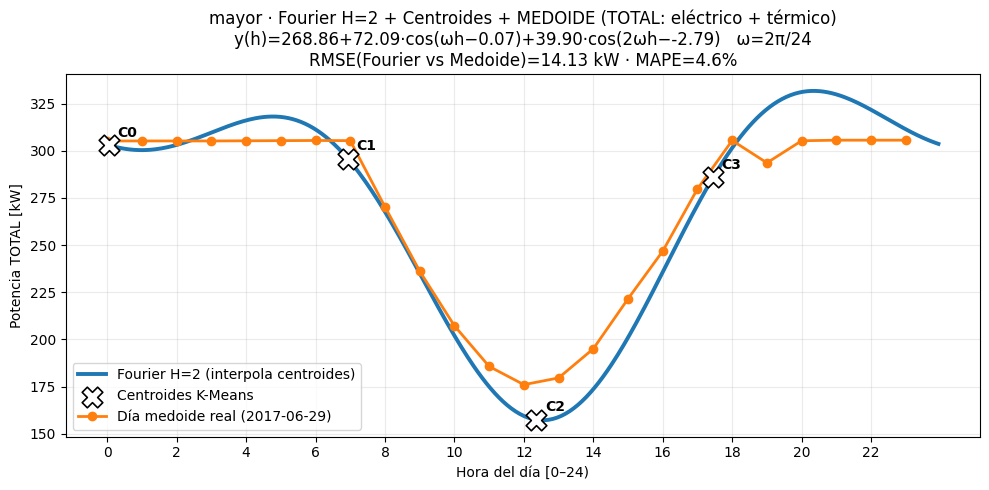


[mayor] Medoide: 2017-06-29
RMSE(Fourier vs Medoide) = 14.128 kW
MAPE(Fourier vs Medoide) = 4.61 %
Serie 24h del medoide (kW TOTAL):
hora
0     305.18
1     305.18
2     305.18
3     305.18
4     305.26
5     305.34
6     305.42
7     305.34
8     270.24
9     236.13
10    207.21
11    185.67
12    176.01
13    179.58
14    195.03
15    221.52
16    246.79
17    279.76
18    305.42
19    293.56
20    305.28
21    305.58
22    305.58
23    305.58
------------------------------------------------------------


In [ ]:
# ===== BLOQUE 14 — Fourier H=2 + Centroides + Día MEDOIDE  =====
# Requisitos previos:
# - kmeans_hora_ciclica(...) y fit_fourier_H2_from_centroids(...)
# - 'resultados' con DF por tamaño: "micro", "pequeno", "mayor"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Utilidades coherentes con bloques previos (kWh -> kW con Δt real) ---
TOTAL_CANDIDATAS = ["kWh_total_all", "kWh_total", "kWh_elec_total", "kWh_total_elec"]
COMP_ELEC = ["kWh_heat_elec", "kWh_light", "kWh_vent", "kWh_pump"]

def _select_total_kWh(df, prefer_col=None):
    """
    Elige serie total en kWh. Si 'prefer_col' existe, se usa.
    Si no, detecta TOTAL (kWh_total_all/variantes) o compone:
       total = (kWh_total_elec o suma de componentes eléctricos) + kWh_fuel_heat (si existe).
    """
    if prefer_col is not None and prefer_col in df.columns:
        s = pd.to_numeric(df[prefer_col], errors="coerce")
    else:
        total_col = next((c for c in TOTAL_CANDIDATAS if c in df.columns), None)
        if total_col is not None:
            s = pd.to_numeric(df[total_col], errors="coerce")
        else:
            # Construir total = eléctrico + térmico
            if "kWh_total_elec" in df.columns:
                elec = pd.to_numeric(df["kWh_total_elec"], errors="coerce")
            else:
                comp = [c for c in COMP_ELEC if c in df.columns]
                elec = df[comp].sum(axis=1, min_count=1) if comp else None
            fuel = pd.to_numeric(df["kWh_fuel_heat"], errors="coerce") if "kWh_fuel_heat" in df.columns else None
            if elec is None and fuel is None:
                raise ValueError("No hay columnas para construir el TOTAL (eléctrico + térmico).")
            if elec is None: elec = pd.Series(0.0, index=df.index, dtype=float)
            if fuel is None: fuel = pd.Series(0.0, index=df.index, dtype=float)
            s = elec.add(fuel, fill_value=0.0)
    return s.replace([np.inf, -np.inf], np.nan)

def _t_sin_tz(df):
    t = pd.to_datetime(df["t"], errors="coerce")
    if getattr(t.dt, "tz", None) is not None:
        t = t.dt.tz_convert("America/Bogota").dt.tz_localize(None)
    return t

def _kWh_a_kW(total_kWh, t):
    dt_h = t.diff().dt.total_seconds().div(3600.0)
    med = dt_h.median() if pd.notna(dt_h.median()) and dt_h.median() > 0 else 1.0
    dt_h = dt_h.fillna(med).clip(lower=0.25, upper=4.0)
    return total_kWh.div(dt_h)

def _pivot_diario_24h(df, prefer_col="kWh_total_all", min_hours=20):
    """
    Matriz (filas=días, columnas=hora 0..23) con POTENCIA [kW] TOTAL.
    Filtra vacío (hay_lote==1) y valores <=0.
    """
    d = df.copy()
    t = _t_sin_tz(d)

    if prefer_col == "kWh_total_all" and "kWh_total_all_tuned" in d.columns:
        prefer_col = "kWh_total_all_tuned"

    kWh = _select_total_kWh(d, prefer_col=prefer_col)
    kW  = _kWh_a_kW(kWh, t)

    d = pd.DataFrame({"t": t, "kW": kW})
    if "hay_lote" in df.columns:
        d["hay_lote"] = pd.to_numeric(df["hay_lote"], errors="coerce").fillna(1).astype("int8").values
        d = d[d["hay_lote"] == 1]

    d["hora"]  = d["t"].dt.hour.astype(int)
    d["fecha"] = d["t"].dt.date
    d = d.replace([np.inf, -np.inf], np.nan).dropna(subset=["kW","hora","fecha"])
    d = d[d["kW"] > 0]

    piv = d.pivot_table(index="fecha", columns="hora", values="kW", aggfunc="mean")
    piv = piv[piv.count(axis=1) >= min_hours]
    piv = piv.reindex(range(24), axis=1)       # asegurar columnas 0..23
    piv = piv.sort_index()
    return piv

def _medoid_day_by_shape(piv):
    """
    Medoide por forma (independiente de magnitud):
      1) Normaliza cada día por su media,
      2) Calcula forma mediana por hora,
      3) Selecciona el día con mínima distancia L1 a esa forma.
    Devuelve: (fecha_medoid, serie_24h_en_kW)
    """
    mean_d   = piv.mean(axis=1).replace(0, np.nan)
    piv_norm = piv.div(mean_d, axis=0)
    mshape   = piv_norm.median(axis=0, skipna=True)
    dist     = (piv_norm.subtract(mshape, axis=1)).abs().sum(axis=1)

    f_med = dist.idxmin()
    s24   = piv.loc[f_med].reindex(range(24))
    return f_med, s24

def _rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.nanmean((y_true - y_pred)**2)))

def _mape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = (y_true > eps) & ~np.isnan(y_true)
    if not np.any(mask):
        return np.nan
    return float(np.nanmean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)

def plot_fourier_centroids_medoide_por_tamano(resultados_dict, K=4,
                                              balance_by_hour=True, per_hour_max=None,
                                              usar_val_col="kWh_total_all", min_hours=20):
    """
    Para cada tamaño:
      1) K-Means (hora cíclica) → centroides (hora_media, kW_centroid) y Fourier H=2 que los interpola.
      2) Día MEDOIDE real (24 h) en kW TOTAL (por defecto).
      3) Gráfico: Fourier (suave, dominio [0,24)) + Centroides + Medoide.
      4) Métricas: RMSE y MAPE (Fourier vs Medoide).
    """
    ESCENES = [k for k in ["micro","pequeno","mayor"] if k in resultados_dict]
    for esc in ESCENES:
        df = resultados_dict[esc]

        # --- 1) Centroides y ajuste Fourier (kW TOTAL)
        df_lab, cents = kmeans_hora_ciclica(df, K=K,
                                            balance_by_hour=balance_by_hour,
                                            per_hour_max=per_hour_max)
        fit = fit_fourier_H2_from_centroids(cents)  # {'f_eval', A0,A1,phi1,...} en kW TOTAL
        ycent = "kW_centroid" if "kW_centroid" in cents.columns else "kWh_centroid"

        # --- 2) Medoide real (kW TOTAL por defecto; puedes pasar "kWh_total_elec" si quieres sólo eléctrico)
        piv = _pivot_diario_24h(df, prefer_col=usar_val_col, min_hours=min_hours)
        if piv.empty:
            print(f"[{esc}] No hay días suficientes para calcular el medoide.")
            continue
        fecha_med, s24_med = _medoid_day_by_shape(piv)

        # --- 3) Curvas (dominio [0,24) sin repetir extremo)
        h_f = np.linspace(0, 24, 400, endpoint=False)
        y_f = fit["f_eval"](h_f)
        hrs = np.arange(24)
        y_fourier_24 = fit["f_eval"](hrs)

        # --- 4) Métricas
        rmse = _rmse(s24_med.values, y_fourier_24)
        mape = _mape(s24_med.values, y_fourier_24)

        # --- 5) Plot
        eq_txt = (f"y(h)={fit['A0']:.2f}"
                  f"+{fit['A1']:.2f}·cos(ωh−{fit['phi1']:.2f})"
                  f"+{fit['A2']:.2f}·cos(2ωh−{fit['phi2']:.2f})   ω=2π/24")

        esc_titulo = {"pequeno": "pequeño"}.get(esc, esc)

        plt.figure(figsize=(10,5))
        plt.plot(h_f, y_f, linewidth=2.8, label="Fourier H=2 (interpola centroides)")
        plt.scatter(cents["hora_media"], cents[ycent],
                    s=220, marker="X", edgecolors="k", linewidths=1.2,
                    facecolors="white", zorder=5, label="Centroides K-Means")
        for i, (_, r) in enumerate(cents.sort_values("hora_media").iterrows()):
            plt.annotate(f"C{i}", (r["hora_media"], r[ycent]),
                         textcoords="offset points", xytext=(6,6),
                         fontsize=10, weight="bold")
        plt.plot(s24_med.index, s24_med.values, marker="o", linewidth=2,
                 label=f"Día medoide real ({fecha_med})")

        plt.title(f"{esc_titulo} · Fourier H=2 + Centroides + MEDOIDE (TOTAL: eléctrico + térmico)\n{eq_txt}\n"
                  f"RMSE(Fourier vs Medoide)={rmse:.2f} kW · MAPE={mape:.1f}%")
        plt.xlabel("Hora del día [0–24)"); plt.ylabel("Potencia TOTAL [kW]")
        plt.xticks(range(0,24,2)); plt.grid(True, alpha=.25); plt.legend()
        plt.tight_layout(); plt.show()

        print(f"\n[{esc_titulo}] Medoide: {fecha_med}")
        print(f"RMSE(Fourier vs Medoide) = {rmse:.3f} kW")
        print(f"MAPE(Fourier vs Medoide) = {mape:.2f} %")
        print("Serie 24h del medoide (kW TOTAL):")
        print(s24_med.round(2).to_string())
        print("-"*60)

plot_fourier_centroids_medoide_por_tamano(
    resultados,
    K=4,
    balance_by_hour=True,
    per_hour_max=None,
    usar_val_col="kWh_total_all",
    min_hours=20
)


/tmp/ipython-input-899011593.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), per_hour_max), random_state=random_state))
/tmp/ipython-input-899011593.py:114: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scale = float(sc.scale_) if float(sc.scale_) != 0.0 else 1.0
/tmp/ipython-input-899011593.py:115: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing th

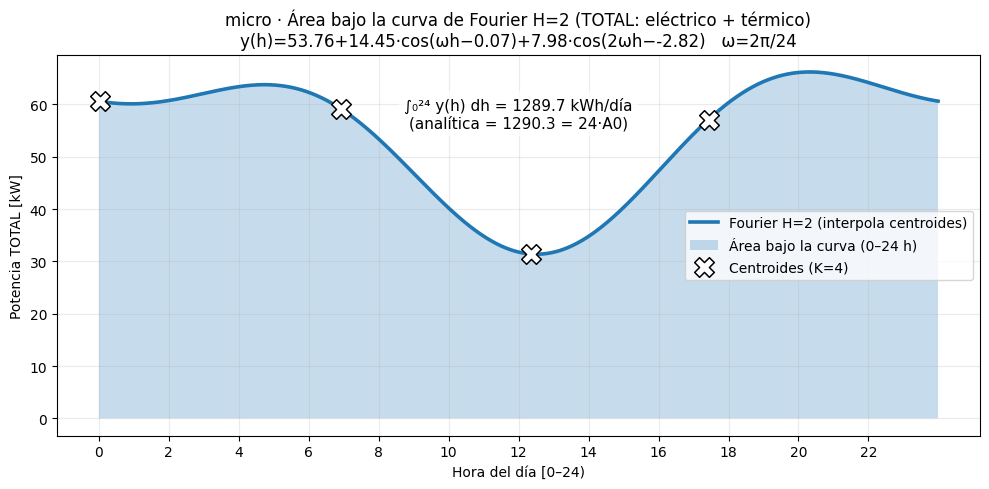

[micro] Área diaria bajo y(h) (Fourier H=2, TOTAL):
  Numérica 0–24 h = 1289.69 kWh/día
  Analítica 0–24 h = 1290.30 kWh/día (24·A0)
  Analítica general 0–24 h = 1290.30 kWh/día
Ecuación:
  y(h) = 53.7623 + 14.4489·cos(ωh − 0.0684) + 7.9821·cos(2ωh − -2.8159);   ω = 2π/24
Centroides (hora_media, kW):
 hora_media  kW_centroid
       0.04        60.57
       6.92        59.17
      12.36        31.41
      17.43        57.12
------------------------------------------------------------


/tmp/ipython-input-899011593.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), per_hour_max), random_state=random_state))
/tmp/ipython-input-899011593.py:114: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scale = float(sc.scale_) if float(sc.scale_) != 0.0 else 1.0
/tmp/ipython-input-899011593.py:115: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing th

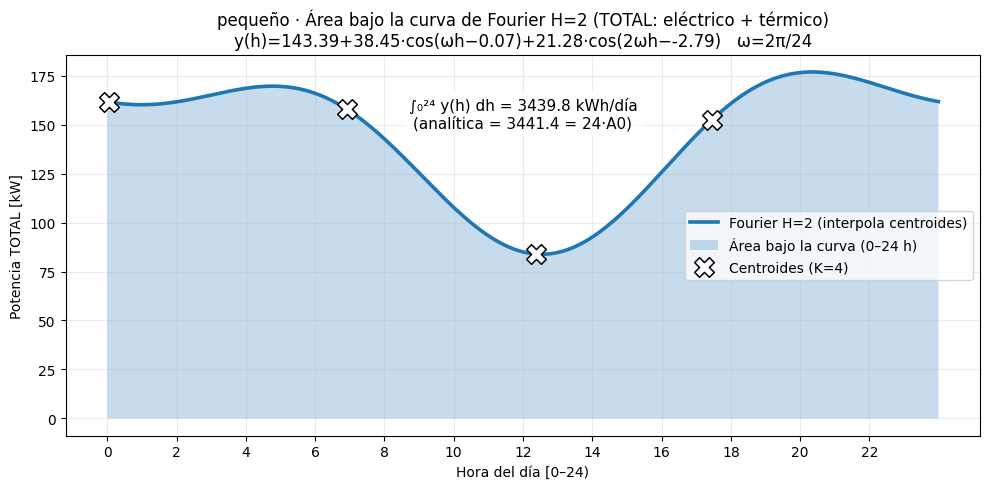

[pequeño] Área diaria bajo y(h) (Fourier H=2, TOTAL):
  Numérica 0–24 h = 3439.78 kWh/día
  Analítica 0–24 h = 3441.39 kWh/día (24·A0)
  Analítica general 0–24 h = 3441.39 kWh/día
Ecuación:
  y(h) = 143.3914 + 38.4493·cos(ωh − 0.0678) + 21.2813·cos(2ωh − -2.7947);   ω = 2π/24
Centroides (hora_media, kW):
 hora_media  kW_centroid
       0.04       161.60
       6.93       157.77
      12.36        83.94
      17.45       152.44
------------------------------------------------------------


/tmp/ipython-input-899011593.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), per_hour_max), random_state=random_state))
/tmp/ipython-input-899011593.py:114: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scale = float(sc.scale_) if float(sc.scale_) != 0.0 else 1.0
/tmp/ipython-input-899011593.py:115: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing th

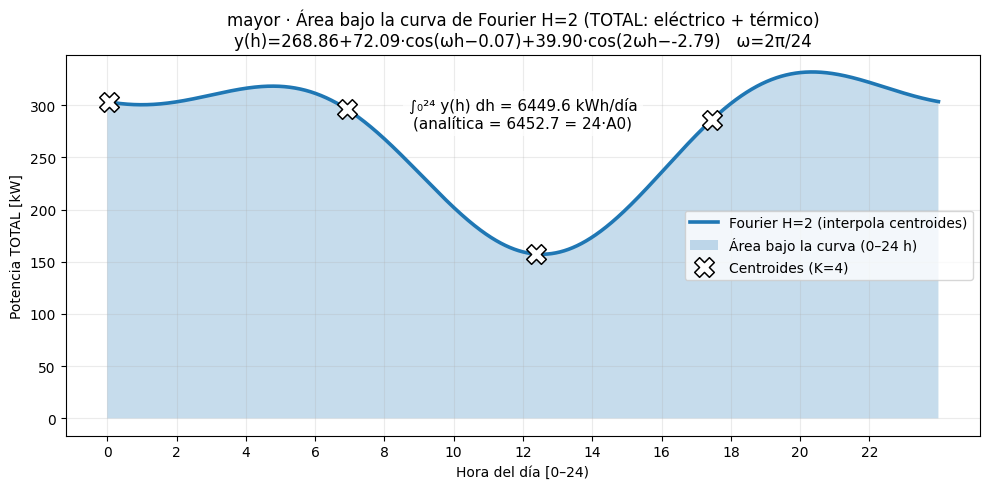

[mayor] Área diaria bajo y(h) (Fourier H=2, TOTAL):
  Numérica 0–24 h = 6449.64 kWh/día
  Analítica 0–24 h = 6452.67 kWh/día (24·A0)
  Analítica general 0–24 h = 6452.67 kWh/día
Ecuación:
  y(h) = 268.8614 + 72.0908·cos(ωh − 0.0678) + 39.9035·cos(2ωh − -2.7947);   ω = 2π/24
Centroides (hora_media, kW):
 hora_media  kW_centroid
       0.04       303.00
       6.93       295.82
      12.36       157.38
      17.45       285.84
------------------------------------------------------------


In [ ]:
# ===== BLOQUE 15 — Área bajo la curva (Fourier H=2) + sombreado + integral (kWh/día, TOTAL) =====
# Requisitos:
#   - kmeans_hora_ciclica(...)  y  fit_fourier_H2_from_centroids(...)
#   - 'resultados' con DataFrames por tamaño: "micro", "pequeno", "mayor"
#
# Qué hace:
#   - Para cada tamaño: obtiene centroides (K=4), ajusta Fourier H=2 que INTERPOLA los centroides
#     y calcula el área ∫ y(h) dh de 0 a 24 horas (un día completo).
#   - Grafica la curva de Fourier con el área sombreada y anota el valor numérico y analítico.
#
# Unidades:
#   - y(h) está en kW  →  ∫ y(h) dh (horas) = kWh por día.

import numpy as np
import matplotlib.pyplot as plt

def integrar_area_fourier(f_eval, h_ini=0.0, h_fin=24.0, n=2400):
    """
    Integra numéricamente y(h)=f_eval(h) entre h_ini y h_fin con trapecios.
    Usa endpoint=False para no duplicar el extremo h_fin.
    Retorna: (area_kWh, h_vector, y_vector).
    """
    h = np.linspace(h_ini, h_fin, int(n), endpoint=False)
    y = f_eval(h)
    area = float(np.trapz(y, h))  # kW * h = kWh
    return area, h, y

def area_analitica_any_interval(A0, A1, phi1, A2, phi2, omega, h_ini=0.0, h_fin=24.0):
    """
    Área analítica para y(h)=A0 + A1·cos(ωh-φ1) + A2·cos(2ωh-φ2) en [h_ini, h_fin].
    ∫ y(h) dh = A0·Δh + (A1/ω)[sin(ωh-φ1)]_a^b + (A2/(2ω))[sin(2ωh-φ2)]_a^b
    """
    dh = float(h_fin - h_ini)
    term1 = A0 * dh
    term2 = (A1 / omega) * (np.sin(omega*h_fin - phi1) - np.sin(omega*h_ini - phi1))
    term3 = (A2 / (2.0*omega)) * (np.sin(2.0*omega*h_fin - phi2) - np.sin(2.0*omega*h_ini - phi2))
    return float(term1 + term2 + term3)

def area_analitica_full_day(A0, omega, h_ini=0.0, h_fin=24.0):
    """
    Atajo analítico cuando el intervalo es un múltiplo del período (24 h):
    las armónicas integran 0 → área = 24·A0.
    """
    T = 2*np.pi/omega if omega != 0 else 24.0
    dur = h_fin - h_ini
    if np.isclose((dur / T) % 1.0, 0.0, atol=1e-8):
        return 24.0 * float(A0)
    return None

def plot_area_fourier_por_tamano(resultados_dict, K=4, balance_by_hour=True, per_hour_max=None):
    ESCENES = [k for k in ["micro","pequeno","mayor"] if k in resultados_dict]
    for esc in ESCENES:
        # 1) K-Means (hora cíclica) y ajuste Fourier H=2
        df_lab, cents = kmeans_hora_ciclica(resultados_dict[esc], K=K,
                                            balance_by_hour=balance_by_hour,
                                            per_hour_max=per_hour_max)
        fit = fit_fourier_H2_from_centroids(cents)  # {'f_eval','A0','A1','phi1','A2','phi2','omega', ...}

        # Soporta centroides en kW o kWh
        ycent = "kW_centroid" if "kW_centroid" in cents.columns else "kWh_centroid"

        # 2) Integración en [0, 24) horas (día completo)
        area_num_kWh, h_f, y_f = integrar_area_fourier(fit["f_eval"], 0.0, 24.0, n=2400)
        area_an_full = area_analitica_full_day(fit["A0"], fit["omega"], 0.0, 24.0)
        area_an_general = area_analitica_any_interval(
            fit["A0"], fit["A1"], fit["phi1"], fit["A2"], fit["phi2"], fit["omega"], 0.0, 24.0
        )

        # 3) Gráfica con área sombreada
        plt.figure(figsize=(10,5))
        plt.plot(h_f, y_f, linewidth=2.6, label="Fourier H=2 (interpola centroides)")
        plt.fill_between(h_f, 0.0, y_f, alpha=0.25, label="Área bajo la curva (0–24 h)")
        # Centroides como referencia
        plt.scatter(cents["hora_media"], cents[ycent],
                    s=200, marker="X", edgecolors="k", linewidths=1.1,
                    facecolors="white", zorder=5, label="Centroides (K=4)")


        y_max = float(np.nanmax(y_f)) if np.size(y_f) else 0.0
        txt = f"∫₀²⁴ y(h) dh = {area_num_kWh:.1f} kWh/día"
        if area_an_full is not None:
            txt += f"\n(analítica = {area_an_full:.1f} = 24·A0)"
        else:
            txt += f"\n(analítica = {area_an_general:.1f})"
        plt.text(12, 0.88*y_max if y_max>0 else 0.0, txt,
                 ha="center", va="center", fontsize=11,
                 bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))


        eq_txt = (f"y(h)={fit['A0']:.2f}"
                  f"+{fit['A1']:.2f}·cos(ωh−{fit['phi1']:.2f})"
                  f"+{fit['A2']:.2f}·cos(2ωh−{fit['phi2']:.2f})   ω=2π/24")

        esc_titulo = {"pequeno": "pequeño"}.get(esc, esc)
        plt.title(f"{esc_titulo} · Área bajo la curva de Fourier H=2 (TOTAL: eléctrico + térmico)\n{eq_txt}")
        plt.xlabel("Hora del día [0–24)")
        plt.ylabel("Potencia TOTAL [kW]")
        plt.xticks(range(0,24,2))
        plt.grid(True, alpha=.25)
        plt.legend()
        plt.tight_layout()
        plt.show()


        print(f"[{esc_titulo}] Área diaria bajo y(h) (Fourier H=2, TOTAL):")
        print(f"  Numérica 0–24 h = {area_num_kWh:.2f} kWh/día")
        if area_an_full is not None:
            print(f"  Analítica 0–24 h = {area_an_full:.2f} kWh/día (24·A0)")
        print(f"  Analítica general 0–24 h = {area_an_general:.2f} kWh/día")
        print("Ecuación:")
        print(f"  y(h) = {fit['A0']:.4f}"
              f" + {fit['A1']:.4f}·cos(ωh − {fit['phi1']:.4f})"
              f" + {fit['A2']:.4f}·cos(2ωh − {fit['phi2']:.4f});   ω = 2π/24")
        print("Centroides (hora_media, kW):")
        print(cents.sort_values('hora_media')[['hora_media', ycent]].round(2).to_string(index=False))
        print("-"*60)

# ===== Ejecutar BLOQUE 15 =====
plot_area_fourier_por_tamano(resultados, K=4, balance_by_hour=True, per_hour_max=None)


In [ ]:
# === Bloque 16 (corregido): áreas por tamaño de granja (+30% áreas de servicio) ==========
# Requiere (si no existen, se definen por defecto):
#   AREA_POR_1000_M2 = 81.0
#   ESCENARIOS = {"micro":2500,"pequeno":8000,"mayor":15000}
# Acepta también:
#   - lista de nombres: ["micro","pequeno","mayor"]
#   - lista de pares:   [("micro",2500), ("pequeno",8000), ("mayor",15000)]

import math
import numbers
import pandas as pd

# --- Defaults seguros ---
try:
    AREA_POR_1000_M2
except NameError:
    AREA_POR_1000_M2 = 81.0  # m² por 1.000 aves

DEFAULTS_AVES = {"micro": 2500, "pequeno": 8000, "mayor": 15000}

try:
    ESCENARIOS
except NameError:
    ESCENARIOS = DEFAULTS_AVES.copy()

# === Factor de sobre-área para mantenimiento / áreas técnicas / sanitarias ===
# Referencia típica en galpones: pasillos (≈10–12%), zonas técnicas (≈8–10%),
# márgenes sanitarios (≈8–10%) → total recomendado ≈30%.
AREA_EXTRA_FRAC = 0.30

# --- Utilidades -----------------------------------------------------------------

_ALIASES = {
    "pequeño": "pequeno",
    "pequenio": "pequeno",
    "mediano": "pequeno",  # sinónimo frecuente
    "grande":  "mayor",    # sinónimo frecuente
}

def _norm_nombre(n):
    n = str(n).strip().lower()
    return _ALIASES.get(n, n)

def _to_float(x):
    """Convierte distintos formatos a float: '8,000', '8 000', 8000, '8000.0'."""
    if x is None:
        raise ValueError("Valor nulo para número de aves.")
    if isinstance(x, numbers.Number):
        return float(x)
    s = str(x).strip().replace(" ", "").replace(",", "")
    return float(s)

def _to_dict_escenarios(esc):
    """Normaliza a dict {nombre: aves} preservando el orden de entrada (si no es set)."""
    if isinstance(esc, dict):
        return {_norm_nombre(k): _to_float(v) for k, v in esc.items()}

    # lista de pares (nombre, aves)
    if isinstance(esc, (list, tuple)) and len(esc) > 0 and isinstance(esc[0], (list, tuple)) and len(esc[0]) == 2:
        return {_norm_nombre(k): _to_float(v) for k, v in esc}

    # lista de nombres -> usa defaults
    if isinstance(esc, (list, tuple)):
        return {_norm_nombre(k): float(DEFAULTS_AVES[_norm_nombre(k)]) for k in esc}

    # set de nombres (el orden no está garantizado)
    if isinstance(esc, set):
        return {_norm_nombre(k): float(DEFAULTS_AVES[_norm_nombre(k)]) for k in esc}

    raise TypeError("ESCENARIOS debe ser dict, lista de nombres o lista de pares (nombre, aves).")

def calcular_areas_por_tamano(escenarios=None, area_por_1000=AREA_POR_1000_M2, extra_frac=AREA_EXTRA_FRAC):
    """
    Devuelve:
      - AREAS_BASE_M2: dict con área base por escenario (solo corral/galpón) [m²]
      - AREAS_M2:      dict con área TOTAL (base + extra_frac) [m²]
      - AREAS_DF:      DataFrame con desglose
    Además imprime un resumen legible.
    """
    if escenarios is None:
        escenarios = ESCENARIOS
    esc_dict = _to_dict_escenarios(escenarios)

    # Validaciones
    if not (0.0 <= float(extra_frac) <= 10.0):
        raise ValueError("extra_frac debe ser un multiplicador razonable en [0, 10].")
    for k, v in esc_dict.items():
        if v <= 0:
            raise ValueError(f"El número de aves debe ser > 0 (escenario '{k}': {v}).")

    # Cálculo base y extra
    area_por_1000 = float(area_por_1000)
    extra_frac = float(extra_frac)

    keys = list(esc_dict.keys())
    areas_base  = {k: area_por_1000 * (esc_dict[k] / 1000.0) for k in keys}
    areas_extra = {k: areas_base[k] * extra_frac for k in keys}
    areas_total = {k: areas_base[k] + areas_extra[k] for k in keys}

    df_out = (
        pd.DataFrame({
            "escenario": keys,
            "n_aves":    [esc_dict[k] for k in keys],
            "area_base_m2":   [areas_base[k]  for k in keys],
            "area_extra_m2":  [areas_extra[k] for k in keys],
            "area_total_m2":  [areas_total[k] for k in keys],
        })
        .assign(
            m2_por_ave_base  = lambda d: d["area_base_m2"]  / d["n_aves"],
            m2_por_ave_total = lambda d: d["area_total_m2"] / d["n_aves"],
            extra_frac       = extra_frac
        )
    )

    # Print bonito
    print("✅ Áreas calculadas por escenario (incluye +30% para pasillos, zonas técnicas y márgenes sanitarios):")
    for k in keys:
        print(f"  - {k:<8}: base={areas_base[k]:.1f} m²  + extra={areas_extra[k]:.1f} m²  → TOTAL={areas_total[k]:.1f} m² "
              f"(aves={int(esc_dict[k])}, m²/ave total={areas_total[k]/esc_dict[k]:.4f})")

    return areas_base, areas_total, df_out

# --- Ejecutar y exponer variables globales útiles --------------------------------
AREAS_BASE_M2, AREAS_M2, AREAS_DF = calcular_areas_por_tamano(
    ESCENARIOS,
    AREA_POR_1000_M2,
    AREA_EXTRA_FRAC
)

# Variables individuales (totales, con +30%); se usan en bloques posteriores (layout, etc.)
AREA_MICRO_M2_TOTAL   = AREAS_M2.get("micro",   float("nan"))
AREA_PEQUENO_M2_TOTAL = AREAS_M2.get("pequeno", float("nan"))
AREA_MAYOR_M2_TOTAL   = AREAS_M2.get("mayor",   float("nan"))

# (Opcional) También las bases por si necesitas comparar
AREA_MICRO_M2_BASE    = AREAS_BASE_M2.get("micro",   float("nan"))
AREA_PEQUENO_M2_BASE  = AREAS_BASE_M2.get("pequeno", float("nan"))
AREA_MAYOR_M2_BASE    = AREAS_BASE_M2.get("mayor",   float("nan"))


✅ Áreas calculadas por escenario (incluye +30% para pasillos, zonas técnicas y márgenes sanitarios):
  - micro   : base=202.5 m²  + extra=60.8 m²  → TOTAL=263.2 m² (aves=2500, m²/ave total=0.1053)
  - pequeno : base=648.0 m²  + extra=194.4 m²  → TOTAL=842.4 m² (aves=8000, m²/ave total=0.1053)
  - mayor   : base=1215.0 m²  + extra=364.5 m²  → TOTAL=1579.5 m² (aves=15000, m²/ave total=0.1053)


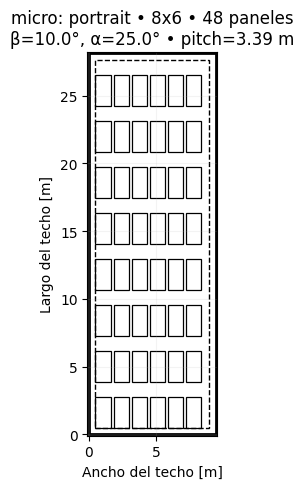

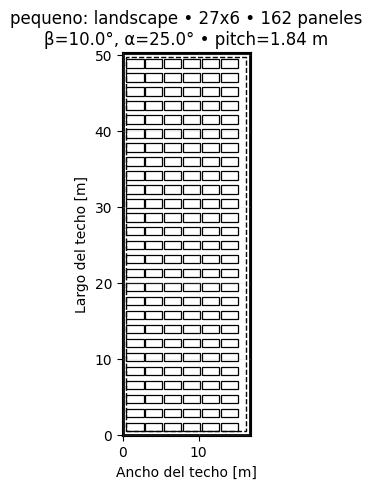

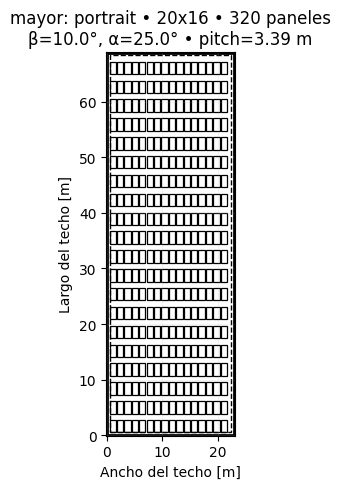

 tamano  area_m2_total orientacion  techo_L_m  techo_W_m  filas  columnas  n_paneles  pot_instalada_kWp  tilt_deg  alpha_deg  proj_panel_m  sombra_m  pitch_m  margen_m  gap_col_m
  mayor        1579.50    portrait      68.84      22.95     20        16        320             172.80      10.0       25.0         2.244     0.849    3.393       0.5        0.2
  micro         263.25    portrait      28.10       9.37      8         6         48              25.92      10.0       25.0         2.244     0.849    3.393       0.5        0.2
pequeno         842.40   landscape      50.27      16.76     27         6        162              87.48      10.0       25.0         1.117     0.422    1.839       0.5        0.2


In [ ]:
# ==Bloque 17= Layout con inclinación y separación anti-sombreo (+30% área servicio aplicado) ===
# Notas:
# - Usa AREAS_M2 del bloque de áreas (+30%) si ya existe.
# - Si no existe, calcula AREAS_M2 = área_base * (1 + AREA_EXTRA_FRAC) con:
#       AREA_POR_1000_M2 (default 81.0), ESCENARIOS (micro/pequeno/mayor) y AREA_EXTRA_FRAC=0.30
# - Justificación del +30%: pasillos (~10–12%), zonas técnicas (~8–10%), márgenes sanitarios/maniobra (~8–10%).

import math
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Panel (EGE ATLAS 530–550 W) ----------
PANEL_LARGO_M = 2.279   # m (lado largo)
PANEL_ANCHO_M = 1.134   # m (lado corto)
PANEL_PMAX_W  = 540     # Wp por panel (ajustable)

# ---------- Asegurar AREAS_M2 (con +30%) ----------
def _ensure_areas_m2():
    if "AREAS_M2" in globals() and isinstance(globals()["AREAS_M2"], dict):
        return globals()["AREAS_M2"]

    esc = globals().get("ESCENARIOS", {"micro": 2500, "pequeno": 8000, "mayor": 15000})
    area_por_1000 = float(globals().get("AREA_POR_1000_M2", 81.0))
    extra_frac = float(globals().get("AREA_EXTRA_FRAC", 0.30))

    # normaliza a dict {nombre: aves}
    if not isinstance(esc, dict):
        try:
            esc = dict(esc)
        except Exception:
            esc = {"micro": 2500, "pequeno": 8000, "mayor": 15000}

    areas_total = {}
    for k, v in esc.items():
        naves = float(v)
        area_base = area_por_1000 * (naves / 1000.0)
        areas_total[str(k)] = area_base * (1.0 + extra_frac)
    return areas_total

AREAS_M2 = _ensure_areas_m2()

# ---------- Parámetros de layout / sombreado ----------
ASPECT_RATIO        = 3.0   # L:W del techo equivalente
MARGEN_M            = 0.50  # margen perimetral (m)
GAP_COL_M           = 0.20  # separación entre columnas (ancho) (m)
GAP_ROW_EXTRA_M     = 0.30  # extra entre filas (pasillo/servicio), además de la sombra (m)
TILT_DEG            = 10.0  # inclinación del módulo (β)
SOLAR_ELEV_MIN_DEG  = 25.0  # altura solar de diseño (α). Usa 20–30° según criterio de no-sombreo
_EPS                = 1e-9  # tolerancia numérica

# ---------- Utilidades ----------
def roof_dims_from_area(area_m2: float, aspect_ratio: float):
    """Devuelve (L, W) con L/W=aspect_ratio y L*W=area."""
    W = (area_m2 / aspect_ratio) ** 0.5
    L = area_m2 / W
    return float(L), float(W)

def pitch_from_tilt_and_alpha(Lp_m: float, tilt_deg: float, alpha_deg: float, gap_extra_m: float):
    """
    Para el lado del panel paralelo a la caída (Lp_m):
      proj = Lp*cos(β), H = Lp*sin(β), sombra S = H/tan(α), pitch = proj + S + extra
    Devuelve (proj, sombra, pitch) en metros.
    """
    beta  = math.radians(tilt_deg)
    alpha = max(1.0, float(alpha_deg))  # evita tan(0)
    H     = Lp_m * math.sin(beta)
    proj  = Lp_m * math.cos(beta)
    shade = H / math.tan(math.radians(alpha))
    pitch = proj + shade + gap_extra_m
    return proj, shade, pitch

def pack_rows_cols(L_eff, W_eff, proj_h, pitch_h, p_w, gap_w):
    """
    Cálculo robusto de repetición:
      - Filas (dirección de la caída): cabe la primera si L_eff >= proj_h.
        Si cabe: 1 + floor((L_eff - proj_h)/pitch_h)
      - Columnas (ancho): cabe la primera si W_eff >= p_w.
        Si cabe: 1 + floor((W_eff - p_w)/(p_w + gap_w))
    """
    if pitch_h <= _EPS or p_w <= _EPS:
        return 0, 0, 0

    # Filas
    if L_eff + _EPS < proj_h:
        n_rows = 0
    else:
        n_rows = 1 + max(0, math.floor((L_eff - proj_h + _EPS) / pitch_h))

    # Columnas
    paso_w = p_w + gap_w
    if W_eff + _EPS < p_w:
        n_cols = 0
    else:
        n_cols = 1 + max(0, math.floor((W_eff - p_w + _EPS) / paso_w))

    return n_rows, n_cols, n_rows * n_cols

def best_orientation_with_tilt(area_m2,
                               tilt_deg=TILT_DEG,
                               alpha_deg=SOLAR_ELEV_MIN_DEG,
                               aspect_ratio=ASPECT_RATIO,
                               margen=MARGEN_M, gap_col=GAP_COL_M, gap_row_extra=GAP_ROW_EXTRA_M):
    """
    Evalúa retrato vs paisaje incluyendo el pitch por sombreado y devuelve la mejor (más paneles).
    """
    L, W = roof_dims_from_area(area_m2, aspect_ratio)
    L_eff, W_eff = max(0.0, L - 2*margen), max(0.0, W - 2*margen)

    # Retrato: Lp = lado largo paralelo a la caída
    proj_r, shade_r, pitch_r = pitch_from_tilt_and_alpha(PANEL_LARGO_M, tilt_deg, alpha_deg, gap_row_extra)
    r_rows, r_cols, r_n = pack_rows_cols(L_eff, W_eff, proj_r, pitch_r, PANEL_ANCHO_M, gap_col)

    # Paisaje: Lp = lado corto paralelo a la caída
    proj_l, shade_l, pitch_l = pitch_from_tilt_and_alpha(PANEL_ANCHO_M, tilt_deg, alpha_deg, gap_row_extra)
    l_rows, l_cols, l_n = pack_rows_cols(L_eff, W_eff, proj_l, pitch_l, PANEL_LARGO_M, gap_col)

    if l_n > r_n:
        orient = "landscape"; rows, cols, n = l_rows, l_cols, l_n
        proj, shade, pitch, p_w = proj_l, shade_l, pitch_l, PANEL_LARGO_M
    else:
        orient = "portrait";  rows, cols, n = r_rows, r_cols, r_n
        proj, shade, pitch, p_w = proj_r, shade_r, pitch_r, PANEL_ANCHO_M

    return {
        "L": L, "W": W, "L_eff": L_eff, "W_eff": W_eff,
        "orient": orient, "rows": rows, "cols": cols, "n": n,
        "panel_proj_h_m": proj,   # huella en la dirección de caída (alto a dibujar)
        "panel_width_m":  p_w,    # huella en el ancho (ancho a dibujar)
        "shade_h_m": shade, "pitch_h_m": pitch,
        "gap_col_m": gap_col, "margen_m": margen,
        "tilt_deg": tilt_deg, "alpha_deg": alpha_deg
    }

def draw_layout_footprint(ax, layout, titulo=""):
    """Dibuja la huella proyectada (alto=panel_proj_h_m, ancho=panel_width_m) y separaciones."""
    L, W = layout["L"], layout["W"]
    margen = layout["margen_m"]
    rows, cols = layout["rows"], layout["cols"]
    p_h = layout["panel_proj_h_m"]
    p_w = layout["panel_width_m"]
    pitch = layout["pitch_h_m"]
    gap_w = layout["gap_col_m"]

    # Techo y zona útil
    ax.add_patch(plt.Rectangle((0,0), W, L, fill=False, linewidth=2))
    ax.add_patch(plt.Rectangle((margen, margen), W-2*margen, L-2*margen, fill=False, linestyle="--", linewidth=1))

    # Paneles como huellas proyectadas
    if rows > 0 and cols > 0:
        x0, y0 = margen, margen
        for i in range(rows):
            for j in range(cols):
                x = x0 + j * (p_w + gap_w)
                y = y0 + i * pitch
                ax.add_patch(plt.Rectangle((x, y), p_w, p_h, fill=False, linewidth=0.9))

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-0.1, W + 0.1); ax.set_ylim(-0.1, L + 0.1)
    ax.set_xlabel("Ancho del techo [m]"); ax.set_ylabel("Largo del techo [m]")
    ax.set_title(titulo); ax.grid(True, alpha=0.15)

# ---------- Cálculo + gráficos ----------
rows = []
orden = [kk for kk in ["micro","pequeno","mayor"] if kk in AREAS_M2] + [kk for kk in AREAS_M2 if kk not in ("micro","pequeno","mayor")]
for k in orden:
    area = float(AREAS_M2[k])
    layout = best_orientation_with_tilt(area)
    n = layout["n"]
    kwp = n * (PANEL_PMAX_W / 1000.0)

    rows.append({
        "tamano": k, "area_m2_total": round(area, 2), "orientacion": layout["orient"],
        "techo_L_m": round(layout["L"], 2), "techo_W_m": round(layout["W"], 2),
        "filas": layout["rows"], "columnas": layout["cols"], "n_paneles": n,
        "pot_instalada_kWp": round(kwp, 2),
        "tilt_deg": layout["tilt_deg"], "alpha_deg": layout["alpha_deg"],
        "proj_panel_m": round(layout["panel_proj_h_m"], 3),
        "sombra_m": round(layout["shade_h_m"], 3),
        "pitch_m": round(layout["pitch_h_m"], 3),
        "margen_m": layout["margen_m"], "gap_col_m": layout["gap_col_m"]
    })

    fig, ax = plt.subplots(figsize=(7,5))
    draw_layout_footprint(
        ax, layout,
        titulo=(f"{k}: {layout['orient']} • {layout['rows']}x{layout['cols']} • {n} paneles\n"
                f"β={layout['tilt_deg']}°, α={layout['alpha_deg']}° • pitch={layout['pitch_h_m']:.2f} m")
    )
    plt.tight_layout(); plt.show(); plt.close()

TABLA_TILT = pd.DataFrame(rows).sort_values("tamano").reset_index(drop=True)
print(TABLA_TILT.to_string(index=False))


In [ ]:
# ==Bloque 18= Área de MÓDULOS FV por tamaño de granja usa +30% de área ===
import math

# ---------------- Panel  ----------------
PANEL_LARGO_M = 2.279
PANEL_ANCHO_M = 1.134
PANEL_AREA_M2 = PANEL_LARGO_M * PANEL_ANCHO_M   # ≈ 2.584 m² por panel
PANEL_PMAX_W  = 540                              # Wp por panel

# ---------------- Asegurar AREAS_M2 con +30% -------------------
def _ensure_areas_m2_plus30():
    """
    Si ya existe AREAS_M2 (del bloque anterior, con +30%), lo usa.
    Si no, lo construye desde ESCENARIOS y AREA_POR_1000_M2 aplicando AREA_EXTRA_FRAC=0.30.
    """
    if "AREAS_M2" in globals() and isinstance(globals()["AREAS_M2"], dict):
        return globals()["AREAS_M2"]

    esc = globals().get("ESCENARIOS", {"micro": 2500, "pequeno": 8000, "mayor": 15000})
    area_por_1000 = float(globals().get("AREA_POR_1000_M2", 81.0))
    extra_frac = float(globals().get("AREA_EXTRA_FRAC", 0.30))  # 30%

    # Normaliza a dict simple
    if not isinstance(esc, dict):
        try:
            esc = dict(esc)
        except Exception:
            esc = {"micro": 2500, "pequeno": 8000, "mayor": 15000}

    areas_total = {}
    for k, v in esc.items():
        naves = float(v)
        area_base = area_por_1000 * (naves / 1000.0)
        areas_total[str(k)] = area_base * (1.0 + extra_frac)
    return areas_total

AREAS_M2 = _ensure_areas_m2_plus30()

# ---------------- Parámetros de layout / sombreado --------------
ASPECT_RATIO        = 3.0    # L/W del techo equivalente
MARGEN_M            = 0.50   # margen perimetral
GAP_COL_M           = 0.20   # separación entre columnas
GAP_ROW_EXTRA_M     = 0.30   # extra entre filas (además de la sombra)
TILT_DEG            = 10.0   # inclinación del panel β
SOLAR_ELEV_MIN_DEG  = 25.0   # altura solar de diseño α
_EPS                = 1e-9   # tolerancia numérica

# ---------------- Utilidades de geometría -----------------------
def roof_dims_from_area(area_m2: float, aspect_ratio: float):
    W = (area_m2 / aspect_ratio) ** 0.5
    L = area_m2 / W
    return float(L), float(W)

def pitch_from_tilt_and_alpha(Lp_m: float, tilt_deg: float, alpha_deg: float, gap_extra_m: float):
    beta  = math.radians(tilt_deg)
    alpha = max(1.0, float(alpha_deg))
    H     = Lp_m * math.sin(beta)
    proj  = Lp_m * math.cos(beta)
    shade = H / math.tan(math.radians(alpha))
    pitch = proj + shade + gap_extra_m
    return proj, pitch

def pack_rows_cols(L_eff, W_eff, proj_h, pitch_h, p_w, gap_w):
    """
    Cálculo robusto (igual filosofía que en Bloque 17):
      - Filas: si L_eff >= proj_h → 1 + floor((L_eff - proj_h)/pitch_h)
      - Columnas: si W_eff >= p_w → 1 + floor((W_eff - p_w)/(p_w + gap_w))
    """
    if pitch_h <= _EPS or p_w <= _EPS:
        return 0, 0, 0

    # Filas
    if L_eff + _EPS < proj_h:
        n_rows = 0
    else:
        n_rows = 1 + max(0, math.floor((L_eff - proj_h + _EPS) / pitch_h))

    # Columnas
    paso_w = p_w + gap_w
    if W_eff + _EPS < p_w:
        n_cols = 0
    else:
        n_cols = 1 + max(0, math.floor((W_eff - p_w + _EPS) / paso_w))

    return n_rows, n_cols, n_rows * n_cols

def n_panels_best_orientation(area_m2):
    L, W = roof_dims_from_area(area_m2, ASPECT_RATIO)
    L_eff, W_eff = max(0.0, L - 2*MARGEN_M), max(0.0, W - 2*MARGEN_M)

    # Retrato
    proj_r, pitch_r = pitch_from_tilt_and_alpha(PANEL_LARGO_M, TILT_DEG, SOLAR_ELEV_MIN_DEG, GAP_ROW_EXTRA_M)
    r_rows, r_cols, r_n = pack_rows_cols(L_eff, W_eff, proj_r, pitch_r, PANEL_ANCHO_M, GAP_COL_M)

    # Paisaje
    proj_l, pitch_l = pitch_from_tilt_and_alpha(PANEL_ANCHO_M, TILT_DEG, SOLAR_ELEV_MIN_DEG, GAP_ROW_EXTRA_M)
    l_rows, l_cols, l_n = pack_rows_cols(L_eff, W_eff, proj_l, pitch_l, PANEL_LARGO_M, GAP_COL_M)

    if l_n > r_n:
        return l_n, "landscape", l_rows, l_cols
    return r_n, "portrait", r_rows, r_cols

# ---------------- Cálculo de área de módulos por tamaño ---------
res_area_modulos = []
orden = [kk for kk in ["micro","pequeno","mayor"] if kk in AREAS_M2] + [kk for kk in AREAS_M2 if kk not in ("micro","pequeno","mayor")]
for k in orden:
    area_techo = float(AREAS_M2[k])
    n, orient, filas, cols = n_panels_best_orientation(area_techo)

    area_mod_m2 = n * PANEL_AREA_M2
    kwp = n * (PANEL_PMAX_W / 1000.0)

    res_area_modulos.append((k, area_techo, n, orient, filas, cols, area_mod_m2, kwp))

# Salida
for k, area_techo, n, orient, filas, cols, area_mod_m2, kwp in res_area_modulos:
    print(f"{k:<8} | techo_total(+30%)={area_techo:8.2f} m² | paneles={n:4d} ({orient:9s} {filas}x{cols}) "
          f"| área_módulos={area_mod_m2:8.2f} m² | kWp≈{kwp:6.2f}")


micro    | techo_total(+30%)=  263.25 m² | paneles=  48 (portrait  8x6) | área_módulos=  124.05 m² | kWp≈ 25.92
pequeno  | techo_total(+30%)=  842.40 m² | paneles= 162 (landscape 27x6) | área_módulos=  418.67 m² | kWp≈ 87.48
mayor    | techo_total(+30%)= 1579.50 m² | paneles= 320 (portrait  20x16) | área_módulos=  827.00 m² | kWp≈172.80


In [ ]:
# =Bloque 19== Densidad energética (kWh/m²·día) usando energía diaria (integral) y TECHO TOTAL +30% ===
import pandas as pd

# 1) ENERGÍA diaria (kWh/día) — valores provenientes de las integrales (∫ y(h) dh 0–24 h)
E_DIARIA_KWH = {
    "micro":   1289.7,
    "pequeno": 3439.8,
    "mayor":   6449.6,
}

# 2) ÁREA de techo TOTAL +30% (m²) — usa exactamente los resultados consolidados
AREAS_TECHO_M2_30 = {
    "micro":   263.25,
    "pequeno": 842.40,
    "mayor":   1579.50,
}

# 3) Validaciones básicas (coincidencia de claves y valores físicos)
esp = {"micro","pequeno","mayor"}
if set(E_DIARIA_KWH) != esp or set(AREAS_TECHO_M2_30) != esp:
    raise ValueError(
        f"Claves no coinciden o faltan. "
        f"E_DIARIA_KWH={list(E_DIARIA_KWH)} | AREAS_TECHO_M2_30={list(AREAS_TECHO_M2_30)}"
    )
if any(v < 0 for v in E_DIARIA_KWH.values()):
    raise ValueError("Hay energías negativas en E_DIARIA_KWH.")
if any(v <= 0 for v in AREAS_TECHO_M2_30.values()):
    raise ValueError("Hay áreas no positivas en AREAS_TECHO_M2_30.")

# 4) Cálculo de densidad diaria por tamaño (kWh/m²·día)
orden = ["micro","pequeno","mayor"]
rows = []
for k in orden:
    E = float(E_DIARIA_KWH[k])            # kWh/día
    A = float(AREAS_TECHO_M2_30[k])       # m² (techo total +30%)
    dens = E / A                          # kWh/m²·día
    rows.append({
        "tamano": k,
        "E_kWh_dia": round(E, 3),
        "A_techo_30_m2": round(A, 2),
        "dens_kWh_m2_dia": round(dens, 6),
    })

df_dens_techo = pd.DataFrame(rows).set_index("tamano")

print("Densidad energética referida al TECHO TOTAL (+30%) — [kWh/m²·día]")
print(df_dens_techo.to_string())

# 5)
DENSIDAD_TECHO_KWH_M2_DIA = df_dens_techo["dens_kWh_m2_dia"].to_dict()


Densidad energética referida al TECHO TOTAL (+30%) — [kWh/m²·día]
         E_kWh_dia  A_techo_30_m2  dens_kWh_m2_dia
tamano                                            
micro       1289.7         263.25         4.899145
pequeno     3439.8         842.40         4.083333
mayor       6449.6        1579.50         4.083318


In [ ]:
# =Bloque 20== Fracción / factor solar (SF) por tipo de galpón ===
import pandas as pd

# Densidad energética diaria de la FUENTE (parábola) [Wh/m²·día]
DENS_FUENTE_WH_M2_DIA = 4186.674
DENS_FUENTE_KWH_M2_DIA = DENS_FUENTE_WH_M2_DIA / 1000.0  # [kWh/m²·día]

orden = ["micro", "pequeno", "mayor"]
rows = []

for k in orden:
    A_techo = float(AREAS_TECHO_M2_30[k])   # m² disponibles (techo +30%)
    E_carga = float(E_DIARIA_KWH[k])        # kWh/día de la CARGA (galpón)

    # Energía diaria POTENCIAL de la fuente solar sobre ese techo
    E_fuente = DENS_FUENTE_KWH_M2_DIA * A_techo   # kWh/día

    # Fracción / factor solar: energía de la fuente / energía de la carga
    SF = E_fuente / E_carga

    rows.append({
        "tamano": k,
        "A_techo_30_m2": round(A_techo, 2),
        "E_carga_kWh_dia": round(E_carga, 3),
        "E_fuente_kWh_dia": round(E_fuente, 3),
        "SF": round(SF, 4),
        "SF_pct": round(SF * 100.0, 2),
    })

df_sf = pd.DataFrame(rows).set_index("tamano")

print("Fracción / factor solar por tamaño de galpón (E_fuente / E_carga):")
print(df_sf.to_string())

# Diccionario utilitario usar SF
SF_POR_TAMANO = df_sf["SF"].to_dict()


Fracción / factor solar por tamaño de galpón (E_fuente / E_carga):
         A_techo_30_m2  E_carga_kWh_dia  E_fuente_kWh_dia      SF  SF_pct
tamano                                                                   
micro           263.25           1289.7          1102.142  0.8546   85.46
pequeno         842.40           3439.8          3526.854  1.0253  102.53
mayor          1579.50           6449.6          6612.852  1.0253  102.53
